In [24]:
import os
import cv2
import json
import joblib
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from tqdm import tqdm
 
import sklearn, sys
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.metrics.pairwise import cosine_similarity
from skimage.feature import hog
 
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python.vision import HandLandmarker, HandLandmarkerOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode
 
from roi_mediapipe import detect_palm_opencv
 
warnings.filterwarnings('ignore')
 
print(f"sklearn : {sklearn.__version__}")
print(f"python  : {sys.executable}")

sklearn : 1.7.2
python  : c:\python313\python.exe


In [25]:
class Config:
    DATASET_PATH = r"D:\xampp\htdocs\palmprint-backend\palmprint-ml\dataset"
    OUTPUT_PATH = "results"
    MODELS_DIR = "models"

    # ROI
    ROI_SIZE = 128
    IMAGE_SIZE = 128

    # HOG (Dioptimalkan untuk menangkap orientasi garis halus dan tebal)
    HOG_ORIENT = 9
    HOG_PIXELS = 16
    HOG_CELLS  = 2
    SGF_ANGLES = np.deg2rad(np.arange(0, 180, 15)) 
    HOG_SGF_WEIGHT = 0.85

    # CLAHE (Pengaman agar kontras lokal tidak terlalu noise)
    CLAHE_CLIP = 1.5 
    CLAHE_TILE = (8, 8)

    # Gabor Filter Bank (Kunci Utama Ekstraksi 4 Fitur)
    GABOR_KSIZE = 21 
    GABOR_SIGMA = 3.5    # Kompromi
    GABOR_LAMBDA = 12.0  # Kompromi
    GABOR_GAMMA = 0.5 
    GABOR_THETAS = np.deg2rad([0, 22.5, 45, 67.5, 90, 112.5, 135, 157.5])

    # PCA
    PCA_VARIANCE = 0.95

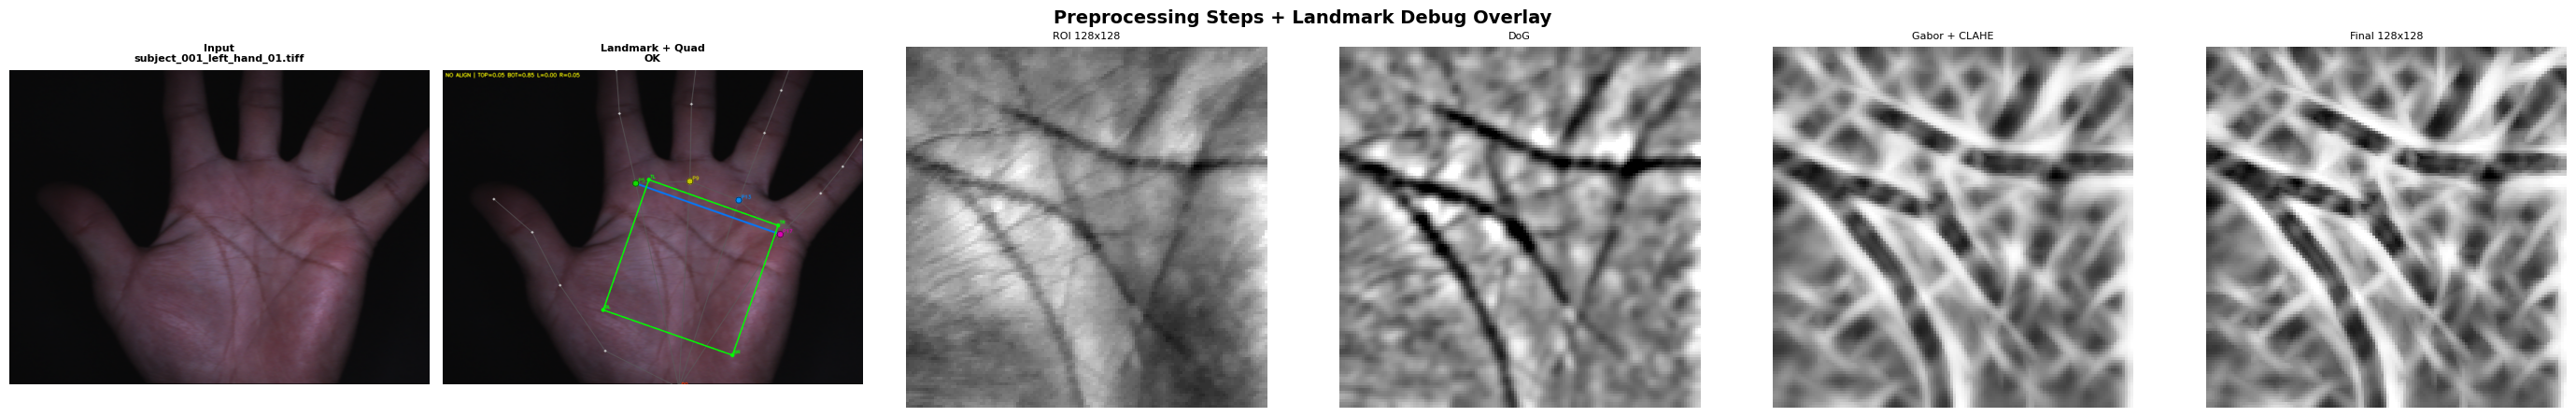

Menampilkan 1 gambar dari total 3000 gambar
Tersimpan: debug_overlay_output.png


In [26]:
def normalize_illumination(img_gray, sigma_small=1.0, sigma_large=5.0):
    img_f = img_gray.astype(np.float32)

    # Tidak ada denoise — langsung DoG seperti training asli
    g_small = cv2.GaussianBlur(img_f, (0, 0), sigmaX=sigma_small)
    g_large = cv2.GaussianBlur(img_f, (0, 0), sigmaX=sigma_large)

    dog = g_small - g_large
    dog = dog - dog.mean()
    lo, hi = np.percentile(dog, [1, 99])
    dog_clipped = np.clip(dog, lo, hi)
    return cv2.normalize(dog_clipped, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def enhance_gabor(img_gray, use_dog=True):
    if use_dog:
        img_gray = normalize_illumination(img_gray)

    responses = []
    scales = [
        {"sigma": 3.5, "lambda": 12.0},
        {"sigma": 2.0, "lambda": 7.0}, 
    ]
    for scale in scales:
        for theta in Config.GABOR_THETAS:
            kernel = cv2.getGaborKernel(
                ksize=(Config.GABOR_KSIZE, Config.GABOR_KSIZE),
                sigma=scale["sigma"],
                theta=theta,
                lambd=scale["lambda"],
                gamma=Config.GABOR_GAMMA,
                psi=0,
                ktype=cv2.CV_32F,
            )
            resp = cv2.filter2D(img_gray.astype(np.float32), cv2.CV_32F, kernel)
            responses.append(np.abs(resp))

    gabor_max = np.max(responses, axis=0)
    gabor_mean = np.mean(responses, axis=0)
    combined = 0.4 * gabor_max + 0.6 * gabor_mean
    combined = cv2.normalize(combined, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=Config.CLAHE_CLIP, tileGridSize=Config.CLAHE_TILE)
    return clahe.apply(combined)

def sharpen_and_resize(img_gray):
    gaussian = cv2.GaussianBlur(img_gray, (5, 5), 2.0)
    sharpened = cv2.addWeighted(img_gray, 1.5, gaussian, -0.5, 0)  # dari 1.8/-0.8
    return cv2.resize(
        sharpened, (Config.IMAGE_SIZE, Config.IMAGE_SIZE), interpolation=cv2.INTER_CUBIC
    )

# ── Visualisasi preprocessing 
exts = (".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif")

samples = sorted(
    [f for f in os.listdir(Config.DATASET_PATH) if f.lower().endswith(exts)]
)
num_samples = min(1, len(samples))

fig, axes = plt.subplots(num_samples, 6, figsize=(28, 4.5 * num_samples))

if num_samples == 1:
    axes = axes.reshape(1, -1)

fig.suptitle(
    "Preprocessing Steps + Landmark Debug Overlay", fontsize=14, fontweight="bold"
)

for row in range(num_samples):

    img_path = os.path.join(Config.DATASET_PATH, samples[row])

    img_s = cv2.imread(img_path)

    # =================================================
    # PIPELINE
    # =================================================
    roi_gray, dbg = detect_palm_opencv(img_s, debug=True)

    dog_s = normalize_illumination(roi_gray)

    gabor_dog_s = enhance_gabor(dog_s, use_dog=False)

    roi_for_hog = sharpen_and_resize(gabor_dog_s)

    status = "FALLBACK" if dbg["fallback"] else "OK"

    # =================================================
    # KOLOM 1 : INPUT
    # =================================================
    axes[row, 0].imshow(cv2.cvtColor(img_s, cv2.COLOR_BGR2RGB))

    axes[row, 0].set_title(f"Input\n{samples[row]}", fontsize=8, fontweight="bold")

    axes[row, 0].axis("off")

    # =================================================
    # KOLOM 2 : LANDMARK + QUAD
    # =================================================
    overlay = dbg.get("debug_overlay", img_s)

    axes[row, 1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))

    axes[row, 1].set_title(
        f"Landmark + Quad\n{status}",
        fontsize=8,
        fontweight="bold",
        color="red" if dbg["fallback"] else "black",
    )

    axes[row, 1].axis("off")

    # =================================================
    # KOLOM 3 : ROI
    # =================================================
    axes[row, 2].imshow(roi_gray, cmap="gray")

    axes[row, 2].set_title(f"ROI {roi_gray.shape[1]}x{roi_gray.shape[0]}", fontsize=8)

    axes[row, 2].axis("off")

    # =================================================
    # KOLOM 4 : DoG
    # =================================================
    axes[row, 3].imshow(dog_s, cmap="gray")

    axes[row, 3].set_title("DoG", fontsize=8)

    axes[row, 3].axis("off")

    # =================================================
    # KOLOM 5 : GABOR + CLAHE
    # =================================================
    axes[row, 4].imshow(gabor_dog_s, cmap="gray")

    axes[row, 4].set_title("Gabor + CLAHE", fontsize=8)

    axes[row, 4].axis("off")

    # =================================================
    # KOLOM 6 : FINAL
    # =================================================
    axes[row, 5].imshow(roi_for_hog, cmap="gray")

    axes[row, 5].set_title(f"Final {Config.IMAGE_SIZE}x{Config.IMAGE_SIZE}", fontsize=8)

    axes[row, 5].axis("off")

plt.tight_layout()

plt.savefig("debug_overlay_output.png", dpi=120, bbox_inches="tight")

plt.show()

print(f"Menampilkan {num_samples} gambar dari total {len(samples)} gambar")

print("Tersimpan: debug_overlay_output.png")

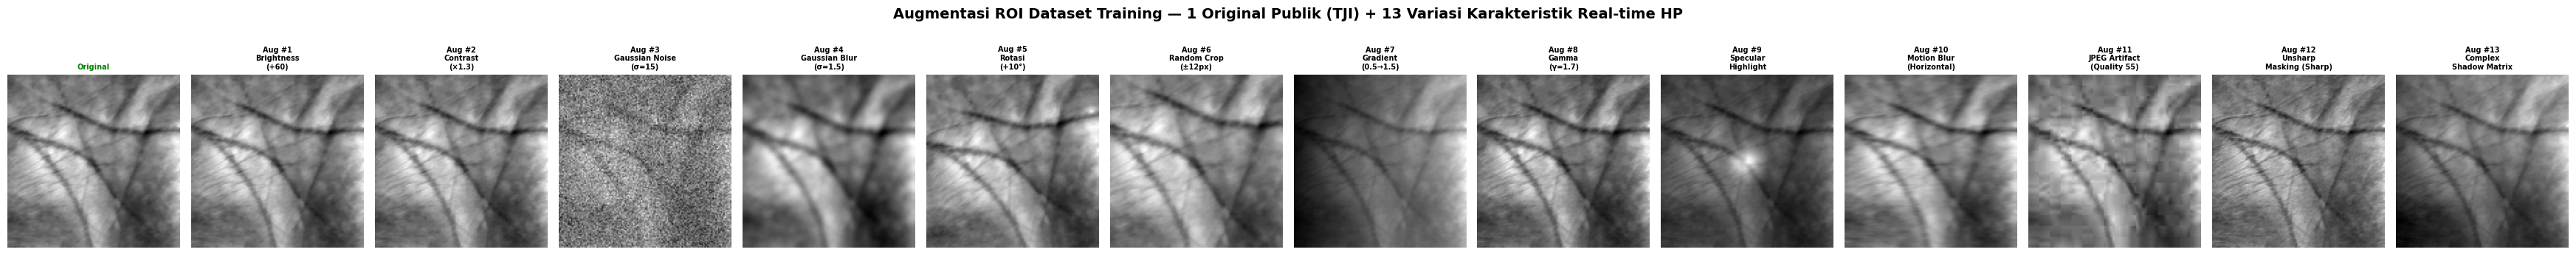

✓ Visualisasi 13 augmentasi data latih selesai dijalankan!
  File laporan aman tersimpan di: results/augmentasi_laporan.png


In [27]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 1. FUNGSI AUGMENTASI (13 Variasi Gangguan Kamera HP)
# =========================================================================
def augment_roi(roi_gray, n_aug=3):
    """
    PREMIUM UPGRADE: Augmentasi ROI Palmprint khusus untuk menjembatani
    Domain Gap antara Dataset Publik (TJI) dengan Kamera HP (Real-time Flutter).
    """
    h, w = roi_gray.shape[:2]
    results = []

    for _ in range(n_aug):
        aug = roi_gray.copy().astype(np.float32)

        # 1. Brightness shift ±60
        if np.random.random() < 0.5:
            aug = np.clip(aug + np.random.uniform(-60, 60), 0, 255)

        # 2. Contrast scaling (Simulasi HDR kamera HP)
        if np.random.random() < 0.5:
            aug = np.clip(aug * np.random.uniform(0.7, 1.3), 0, 255)

        # 3. Gaussian noise (Simulasi ISO tinggi / low-light HP)
        if np.random.random() < 0.5:
            noise = np.random.normal(0, np.random.uniform(5, 15), aug.shape)
            aug = np.clip(aug + noise, 0, 255)

        # 4. Gaussian blur ringan
        if np.random.random() < 0.4:
            aug = cv2.GaussianBlur(aug, (0, 0), np.random.uniform(0.5, 1.5))

        # 5. Rotasi kecil ±10°
        if np.random.random() < 0.6:
            angle = np.random.uniform(-10, 10)
            M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
            aug = cv2.warpAffine(aug, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

        # 6. Random crop + resize balik
        if np.random.random() < 0.5:
            margin = 15
            x1 = np.random.randint(0, margin)
            y1 = np.random.randint(0, margin)
            x2 = w - np.random.randint(0, margin)
            y2 = h - np.random.randint(0, margin)
            aug = cv2.resize(aug[y1:y2, x1:x2], (w, h), interpolation=cv2.INTER_LINEAR)

        # 7. Brightness gradient (Simulasi bayangan HP menutup sebagian telapak)
        if np.random.random() < 0.5:
            gradient = np.linspace(np.random.uniform(0.5, 0.9), np.random.uniform(1.1, 1.5), w).astype(np.float32)
            aug = np.clip(aug * gradient[np.newaxis, :], 0, 255)

        # 8. Gamma correction (Simulasi auto-exposure otomatis milik Android/iOS)
        if np.random.random() < 0.5:
            gamma = np.random.uniform(0.5, 1.8)
            aug_norm = np.clip(aug / 255.0, 1e-7, 1.0)
            aug = np.clip(255.0 * (aug_norm ** gamma), 0, 255)

        # 9. Specular highlight (Titik pantul kilatan lampu flash/ruangan)
        if np.random.random() < 0.4:
            cx = np.random.randint(20, w - 20)
            cy = np.random.randint(20, h - 20)
            radius = np.random.randint(10, 30)
            Y_grid, X_grid = np.ogrid[:h, :w]
            dist = np.sqrt((X_grid - cx)**2 + (Y_grid - cy)**2)
            mask = (dist <= radius).astype(np.float32)
            intensity = np.random.uniform(60, 110)
            falloff = np.clip(1 - dist / radius, 0, 1) ** 2
            aug = np.clip(aug + intensity * falloff * mask, 0, 255)

        # 10. Motion blur ringan (Efek tangan tremor saat menekan tombol capture)
        if np.random.random() < 0.3:
            ksize = np.random.choice([3, 5])
            angle = np.random.uniform(0, 180)
            kernel = np.zeros((ksize, ksize), dtype=np.float32)
            kernel[ksize // 2, :] = 1.0 / ksize
            M_rot = cv2.getRotationMatrix2D((float(ksize // 2), float(ksize // 2)), angle, 1)
            kernel = cv2.warpAffine(kernel, M_rot, (ksize, ksize))
            aug = cv2.filter2D(aug.astype(np.float32), -1, kernel)

        # 11. JPG compression artifact (Khas gambar yang dikirim via HTTP POST)
        if np.random.random() < 0.4:
            quality = np.random.randint(55, 80)
            _, enc = cv2.imencode('.jpg', aug.astype(np.uint8), [cv2.IMWRITE_JPEG_QUALITY, quality])
            aug = cv2.imdecode(enc, cv2.IMREAD_GRAYSCALE).astype(np.float32)

        # 12. Unsharp Masking (Simulasi Ketajaman Sensor HP Modern)
        if np.random.random() < 0.4:
            blur_for_sharp = cv2.GaussianBlur(aug, (5, 5), 1.0)
            aug = np.clip(aug + np.random.uniform(0.5, 1.5) * (aug - blur_for_sharp), 0, 255)

        # 13. Complex Shadow Matrix (Simulasi Bayangan Jari/HP Diagonal)
        if np.random.random() < 0.4:
            Y_grid, X_grid = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
            shadow_pattern = (X_grid * np.random.uniform(-0.5, 0.5) + Y_grid * np.random.uniform(-0.5, 0.5))
            shadow_pattern = cv2.normalize(shadow_pattern, None, 0.6, 1.0, cv2.NORM_MINMAX)
            aug = np.clip(aug * shadow_pattern, 0, 255)

        results.append(aug.astype(np.uint8))

    return results


# =========================================================================
# 2. VISUALISASI DETERMINISTIK UNTUK LAPORAN BAB 3 / BAB 4
# =========================================================================
os.makedirs('results', exist_ok=True)

try:
    # Menggunakan fungsi bawaan dari file training utama kamu untuk ekstrak sampel pertama
    # Pastikan 'img_s' adalah variabel gambar mentah orisinal yang valid dari dataset publik
    roi_s, _ = detect_palm_opencv(img_s) 
    h, w = roi_s.shape[:2]

    # Fungsi pembantu untuk menghasilkan efek tunggal yang stabil (bukan acak) khusus visualisasi laporan
    def apply_single_deterministic(roi, aug_type):
        aug = roi.copy().astype(np.float32)
        if aug_type == 1:    # Brightness shift
            aug = np.clip(aug + 60, 0, 255)
        elif aug_type == 2:  # Contrast scaling
            aug = np.clip(aug * 1.3, 0, 255)
        elif aug_type == 3:  # Gaussian noise
            noise = np.random.normal(0, 15, aug.shape)
            aug = np.clip(aug + noise, 0, 255)
        elif aug_type == 4:  # Gaussian blur
            aug = cv2.GaussianBlur(aug, (0, 0), 1.5)
        elif aug_type == 5:  # Rotasi
            M = cv2.getRotationMatrix2D((w//2, h//2), 10, 1.0)
            aug = cv2.warpAffine(aug, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
        elif aug_type == 6:  # Random crop
            x1, y1, x2, y2 = 12, 12, w-12, h-12
            aug = cv2.resize(aug[y1:y2, x1:x2], (w, h), interpolation=cv2.INTER_LINEAR)
        elif aug_type == 7:  # Brightness gradient
            gradient = np.linspace(0.5, 1.5, w).astype(np.float32)
            aug = np.clip(aug * gradient[np.newaxis, :], 0, 255)
        elif aug_type == 8:  # Gamma correction
            aug_norm = np.clip(aug / 255.0, 1e-7, 1.0)
            aug = np.clip(255.0 * (aug_norm ** 1.7), 0, 255)
        elif aug_type == 9:  # Specular Highlight
            cx, cy, radius = w//2, h//2, 22
            Y_grid, X_grid = np.ogrid[:h, :w]
            dist = np.sqrt((X_grid - cx)**2 + (Y_grid - cy)**2)
            mask = (dist <= radius).astype(np.float32)
            falloff = np.clip(1 - dist / radius, 0, 1) ** 2
            aug = np.clip(aug + 90 * falloff * mask, 0, 255)
        elif aug_type == 10: # Motion Blur
            kernel = np.zeros((5, 5), dtype=np.float32)
            kernel[2, :] = 1.0 / 5
            aug = cv2.filter2D(aug, -1, kernel)
        elif aug_type == 11: # JPEG Artifact
            _, enc = cv2.imencode('.jpg', aug.astype(np.uint8), [cv2.IMWRITE_JPEG_QUALITY, 55])
            aug = cv2.imdecode(enc, cv2.IMREAD_GRAYSCALE)
        elif aug_type == 12: # Unsharp Masking
            blur_for_sharp = cv2.GaussianBlur(aug, (5, 5), 1.0)
            aug = np.clip(aug + 1.5 * (aug - blur_for_sharp), 0, 255)
        elif aug_type == 13: # Complex Shadow Matrix
            Y_grid, X_grid = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
            shadow_pattern = (X_grid * 0.3 + Y_grid * -0.3)
            shadow_pattern = cv2.normalize(shadow_pattern, None, 0.5, 1.0, cv2.NORM_MINMAX)
            aug = np.clip(aug * shadow_pattern, 0, 255)
            
        return aug.astype(np.uint8)

    labels = [
        'Original',
        'Aug #1\nBrightness\n(+60)',
        'Aug #2\nContrast\n(×1.3)',
        'Aug #3\nGaussian Noise\n(σ=15)',
        'Aug #4\nGaussian Blur\n(σ=1.5)',
        'Aug #5\nRotasi\n(+10°)',
        'Aug #6\nRandom Crop\n(±12px)',
        'Aug #7\nGradient\n(0.5→1.5)',
        'Aug #8\nGamma\n(γ=1.7)',
        'Aug #9\nSpecular\nHighlight',
        'Aug #10\nMotion Blur\n(Horizontal)',
        'Aug #11\nJPEG Artifact\n(Quality 55)',
        'Aug #12\nUnsharp\nMasking (Sharp)',
        'Aug #13\nComplex\nShadow Matrix'
    ]

    # Gabungkan gambar asli dengan 13 variasi augmentasi secara berurutan
    aug_images = [roi_s] + [apply_single_deterministic(roi_s, i) for i in range(1, 14)]

    # Plot diperlebar menjadi 1 baris, 14 kolom agar muat semua jenis augmentasi
    fig, axes = plt.subplots(1, 14, figsize=(35, 4))
    fig.suptitle("Augmentasi ROI Dataset Training — 1 Original Publik (TJI) + 13 Variasi Karakteristik Real-time HP", 
                 fontsize=14, fontweight="bold")

    for i, (img_aug, label) in enumerate(zip(aug_images, labels)):
        axes[i].imshow(img_aug, cmap='gray')
        color = 'green' if i == 0 else 'black'
        axes[i].set_title(label, fontweight='bold', color=color, fontsize=7)
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('results/augmentasi_laporan.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Visualisasi 13 augmentasi data latih selesai dijalankan!")
    print("  File laporan aman tersimpan di: results/augmentasi_laporan.png")

except NameError as e:
    print(f"Error: Variabel gambar atau fungsi deteksi belum siap. Detail: {e}")
    print("Pastikan cell pembacaan dataset utama ('img_s') dan fungsi 'detect_palm_opencv' sudah di-run terlebih dahulu sebelum cell ini.")

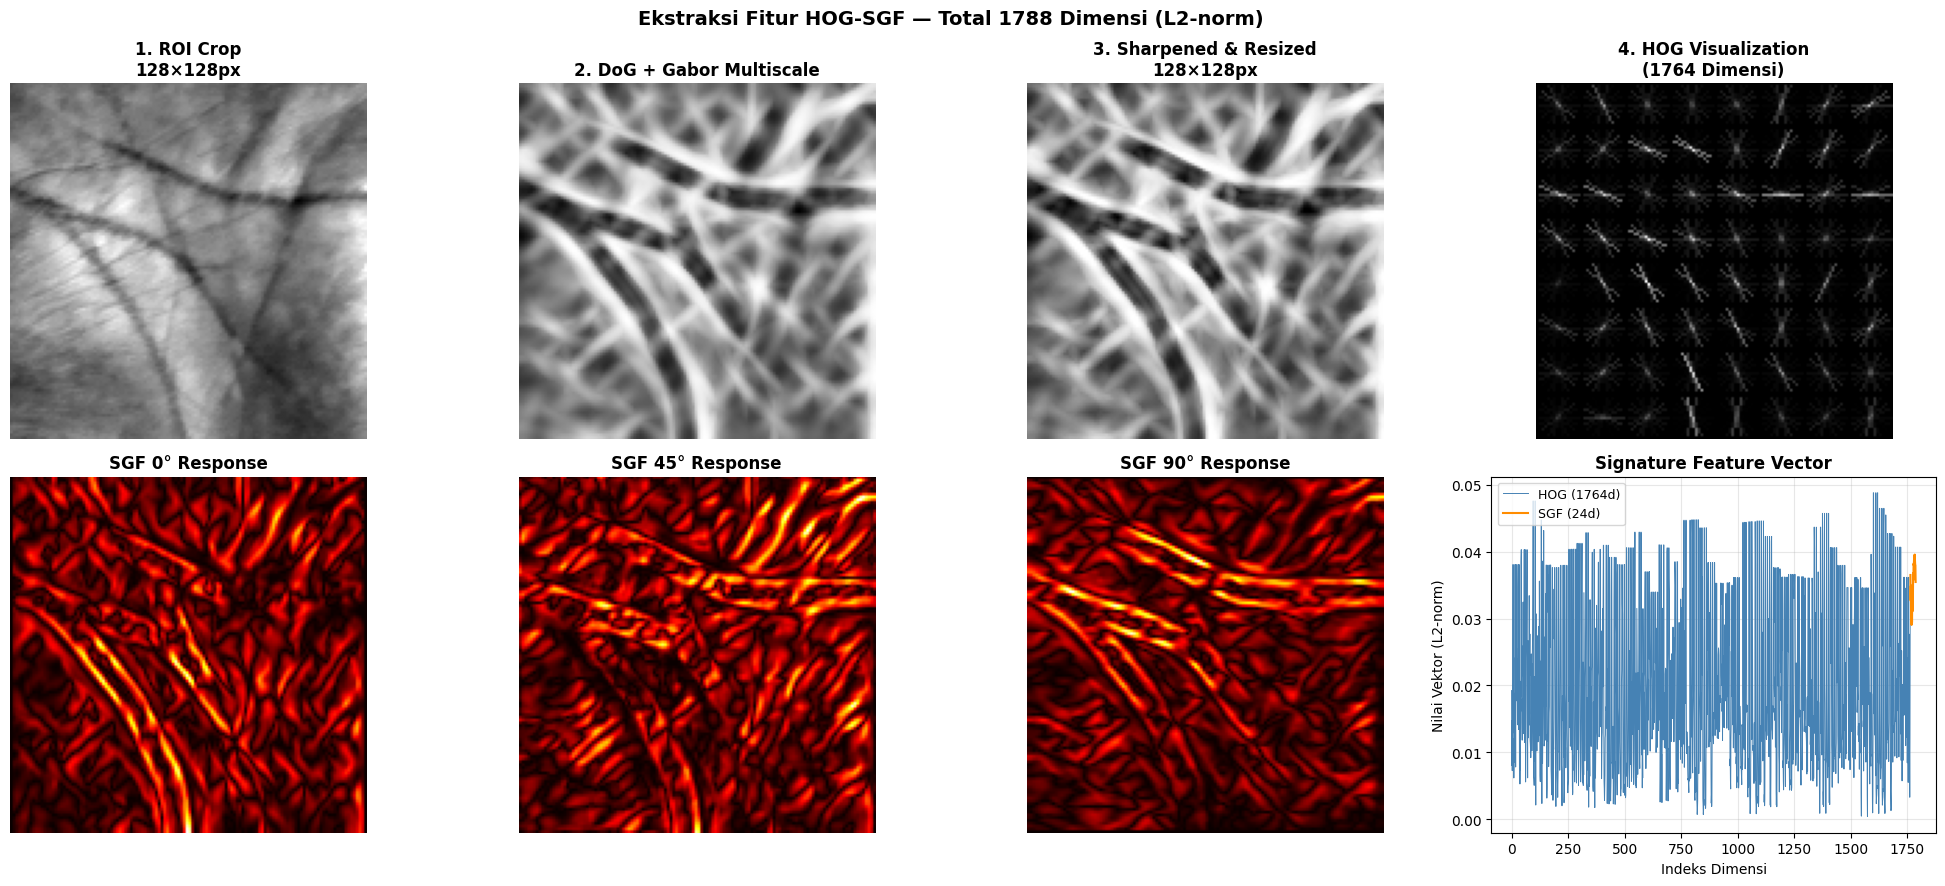

✓ Sukses! Dimensi Ekstraksi Fitur Baru: 1788 (1764d HOG + 24d SGF)


In [28]:
def extract_hog_sgf(img_gray, hog_orient=None, hog_pixels=None,
                    hog_cells=None, visualize=False):
    orient = hog_orient or Config.HOG_ORIENT
    pixels = hog_pixels or Config.HOG_PIXELS
    cells  = hog_cells  or Config.HOG_CELLS

    img_64 = cv2.resize(img_gray, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))

    # ── 1. HOG ──
    if visualize:
        hog_feat, hog_img = hog(
            img_64, orientations=orient,
            pixels_per_cell=(pixels, pixels),
            cells_per_block=(cells, cells),
            block_norm='L2-Hys',        
            visualize=True
        )
    else:
        hog_feat = hog(
            img_64, orientations=orient,
            pixels_per_cell=(pixels, pixels),
            cells_per_block=(cells, cells),
            block_norm='L2-Hys',       
            visualize=False
        )
        hog_img = None

    # ── 2. SGF ──
    img_f = img_64.astype(np.float32)
    Ix    = cv2.Sobel(img_f, cv2.CV_32F, 1, 0, ksize=3)
    Iy    = cv2.Sobel(img_f, cv2.CV_32F, 0, 1, ksize=3)

    sgf_feats = []
    sgf_responses_vis = {}

    for theta in Config.SGF_ANGLES:
        FR     = np.cos(theta) * Ix + np.sin(theta) * Iy
        FR_abs = np.abs(FR)                           
        sgf_feats.extend([np.mean(FR_abs), np.std(FR_abs)])  

        theta_deg = int(np.degrees(theta))
        if visualize and theta_deg in [0, 45, 90]:
            sgf_responses_vis[theta_deg] = FR_abs.copy()   

    sgf_feat = np.array(sgf_feats, dtype=np.float32)

    # ── 3. KOMBINASI & L2-NORMALIZATION ──
    hog_norm = hog_feat / np.maximum(np.linalg.norm(hog_feat), 1e-8)
    sgf_norm = sgf_feat / np.maximum(np.linalg.norm(sgf_feat), 1e-8)
    combined = np.concatenate([hog_norm * Config.HOG_SGF_WEIGHT,
                                sgf_norm * (1 - Config.HOG_SGF_WEIGHT)])
    total_norm = np.linalg.norm(combined)
    if total_norm > 0:
        combined = combined / total_norm

    if visualize:
        return combined, hog_img, img_64, sgf_responses_vis
    return combined
 
 
# ── REVISI VISUALISASI EKSTRAKSI FITUR PADA SAMPEL DATASET DATA LATIH ──
if 'roi_s' in locals() or 'roi_s' in globals():
    dog_s = normalize_illumination(roi_s)   
    enh_s = enhance_gabor(dog_s, use_dog=False) 
    sharpened_s = sharpen_and_resize(enh_s)
    
    feat_s, hog_img_s, img64_s, sgf_responses_s = extract_hog_sgf(sharpened_s, visualize=True)
 
    sgf_dim = len(Config.SGF_ANGLES) * 2
    hog_dim = len(feat_s) - sgf_dim
 
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle(f'Ekstraksi Fitur HOG-SGF — Total {len(feat_s)} Dimensi (L2-norm)', fontsize=14, fontweight='bold')
 
    # Row 0: Tahapan Citra Preprocessing & Descriptor
    axes[0, 0].imshow(roi_s, cmap='gray')
    axes[0, 0].set_title(f'1. ROI Crop\n{roi_s.shape[1]}×{roi_s.shape[0]}px', fontweight='bold')
    axes[0, 0].axis('off')
 
    axes[0, 1].imshow(enh_s, cmap='gray')
    axes[0, 1].set_title('2. DoG + Gabor Multiscale', fontweight='bold')
    axes[0, 1].axis('off')
 
    # REVISI JUDUL KOTAK: Menampilkan citra hasil penajaman yang siap diekstrak oleh HOG
    axes[0, 2].imshow(img64_s, cmap='gray')
    axes[0, 2].set_title(f'3. Sharpened & Resized\n{Config.IMAGE_SIZE}×{Config.IMAGE_SIZE}px', fontweight='bold')
    axes[0, 2].axis('off')
 
    axes[0, 3].imshow(hog_img_s, cmap='gray')
    axes[0, 3].set_title(f'4. HOG Visualization\n({hog_dim} Dimensi)', fontweight='bold')
    axes[0, 3].axis('off')
 
    # Row 1: Menampilkan Respon SGF Tanpa Perlu Kalkulasi Ulang (Mengambil dari Dictionary)
    vis_mapping = [(0, 'SGF 0° Response'), (45, 'SGF 45° Response'), (90, 'SGF 90° Response')]
    
    for col, (deg, title) in enumerate(vis_mapping):
        if deg in sgf_responses_s:
            FR_matrix = sgf_responses_s[deg]
            FR_n = cv2.normalize(np.abs(FR_matrix), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            axes[1, col].imshow(FR_n, cmap='hot')
            axes[1, col].set_title(title, fontweight='bold')
        else:
            axes[1, col].text(0.5, 0.5, f'{deg}° Not In Config', ha='center', va='center', fontweight='bold')
        axes[1, col].axis('off')
 
    # Plot gabungan representasi nilai array fitur
    axes[1, 3].plot(feat_s[:hog_dim], lw=0.7, color='steelblue', label=f'HOG ({hog_dim}d)')
    axes[1, 3].plot(range(hog_dim, hog_dim + sgf_dim), feat_s[hog_dim:], lw=1.5, color='darkorange', label=f'SGF ({sgf_dim}d)')
    axes[1, 3].set_title(f'Signature Feature Vector', fontweight='bold')
    axes[1, 3].legend(fontsize=9)
    axes[1, 3].grid(True, alpha=0.3)
    axes[1, 3].set_xlabel('Indeks Dimensi')
    axes[1, 3].set_ylabel('Nilai Vektor (L2-norm)')
 
    plt.tight_layout()
    plt.show()
    print(f'✓ Sukses! Dimensi Ekstraksi Fitur Baru: {len(feat_s)} ({hog_dim}d HOG + {sgf_dim}d SGF)')


[5] Loading dataset (clean, no augmentation)...
  Total file : 3000


Loading: 100%|██████████| 3000/3000 [05:44<00:00,  8.70it/s]



✓ Dataset loaded (original only):
  Skipped    : ~392 gambar (fallback/corrupt)
  Total      : 2608 samples | 297 subjects
  Min/Max    : 1 / 10 per subject
  Feature dim: 1788
  ROI buffer : 40.8 MB

[5b] Membuat template dan query split...
  Subjects di-skip (< 4 gambar): 22 → [np.str_('007'), np.str_('036'), np.str_('049'), np.str_('075'), np.str_('080'), np.str_('083'), np.str_('127'), np.str_('129'), np.str_('134'), np.str_('145'), np.str_('147'), np.str_('178'), np.str_('194'), np.str_('196'), np.str_('200'), np.str_('202'), np.str_('222'), np.str_('250'), np.str_('261'), np.str_('276'), np.str_('284'), np.str_('293')]

[5c] Augmentasi template (post-split, no leakage)...


Augmenting templates: 100%|██████████| 825/825 [03:42<00:00,  3.71it/s]



✓ Augmentasi selesai:
  Template   : 825 samples
  Augmented  : 4950 samples (6× per template)
  Total train: 5775 samples

✓ Split summary:
  Template (original) : 825 (275 subjects × 3 foto)
  Augmented           : 4950 (275 subjects × 6 aug × 3 foto)
  Total train         : 5775
  Query (test)        : 1736 (275 subjects)
  Overlap subjects    : 275 (harus 300!)
  Leakage check       : ✅ AMAN


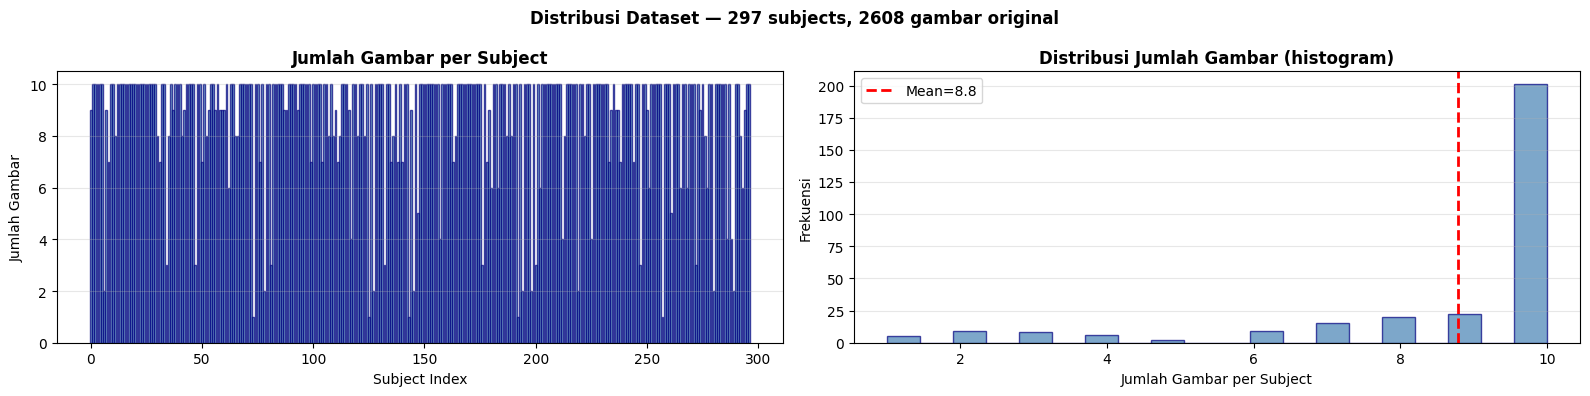

  Min per kelas: 1, Max: 10, Rata-rata: 8.8


In [29]:

# =====================================================================
# BAGIAN 5 — LOAD DATASET + SPLIT + AUGMENTASI
# =====================================================================

def parse_label(fname):
    """
    Ekstrak subject ID dari nama file.
    Format yang didukung: subject_282_left_hand_08.tiff
    Fallback: bagian pertama nama file.
    """
    name  = os.path.splitext(fname)[0]
    parts = name.split('_')
    for part in parts:
        if part.isdigit():
            return part
    return parts[0]

def load_dataset_clean(dataset_path, verbose=True):
    """
    Load dataset TANPA augmentasi — simpan ROI asli untuk augmentasi post-split.
    
    Returns:
        X    : feature matrix (n_samples × n_features)
        y    : label array
        rois : ROI grayscale asli (n_samples × 200 × 200) — untuk augmentasi nanti
    """
    features, labels, rois = [], [], []

    exts  = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
    files = [f for f in os.listdir(dataset_path) if f.lower().endswith(exts)]

    if verbose:
        print(f'  Total file : {len(files)}')

    for fname in tqdm(files, desc='Loading', disable=not verbose):
        img = cv2.imread(os.path.join(dataset_path, fname))
        if img is None:
            continue

        label      = parse_label(fname)
        roi, dbg   = detect_palm_opencv(img)

        if dbg['fallback']:
            continue  # skip — center crop tidak valid untuk biometrik

        # ── SINKRONISASI PIPELINE BARU (DATA LATIH ORIGINAL) ──
        dog_s = normalize_illumination(roi)
        enh_s = enhance_gabor(dog_s, use_dog=False) # use_dog=False karena sudah lewat baris atas
        sharpened_s = sharpen_and_resize(enh_s)
        
        # Ekstraksi Descriptor Gabungan
        feat = extract_hog_sgf(sharpened_s, visualize=False)

        features.append(feat)
        labels.append(label)
        rois.append(roi)

    X    = np.array(features)
    y    = np.array(labels)
    rois = np.array(rois, dtype=np.uint8)   # shape: (N, 200, 200)

    if verbose:
        skipped = len([f for f in os.listdir(dataset_path) 
                       if f.lower().endswith(exts)]) - len(X)
        unique, counts = np.unique(y, return_counts=True)
        ram_mb = rois.nbytes / 1024 / 1024
        print(f'\n✓ Dataset loaded (original only):')
        print(f'  Skipped    : ~{skipped} gambar (fallback/corrupt)')
        print(f'  Total      : {len(X)} samples | {len(unique)} subjects')
        print(f'  Min/Max    : {counts.min()} / {counts.max()} per subject')
        print(f'  Feature dim: {X.shape[1]}')
        print(f'  ROI buffer : {ram_mb:.1f} MB')

    return X, y, rois


def augment_template_only(X_template, y_template, rois_template, n_aug=3, verbose=True):
    """
    Augmentasi HANYA pada template (training set) di level ROI.
    Dipanggil SETELAH split — tidak ada leakage ke test set.

    Pipeline per sample:
        ROI asli → augment_roi() → Preprocessing Baru → extract_hog_sgf()

    Returns:
        X_aug : feature matrix augmented (n_template * n_aug × n_features)
        y_aug : label array augmented
    """
    X_aug_list, y_aug_list = [], []

    for roi, label in tqdm(
        zip(rois_template, y_template),
        total=len(y_template),
        desc='Augmenting templates',
        disable=not verbose
    ):
        for aug_roi in augment_roi(roi, n_aug=n_aug):
            # ── SINKRONISASI PIPELINE BARU (DATA AUGMENTASI) ──
            dog_aug = normalize_illumination(aug_roi)
            enh_aug = enhance_gabor(dog_aug, use_dog=False)
            sharpened_aug = sharpen_and_resize(enh_aug)
            
            aug_feat = extract_hog_sgf(sharpened_aug, visualize=False)
            X_aug_list.append(aug_feat)
            y_aug_list.append(label)

    X_aug = np.array(X_aug_list)
    y_aug = np.array(y_aug_list)

    if verbose:
        print(f'\n✓ Augmentasi selesai:')
        print(f'  Template   : {len(X_template)} samples')
        print(f'  Augmented  : {len(X_aug)} samples ({n_aug}× per template)')
        print(f'  Total train: {len(X_template) + len(X_aug)} samples')

    return X_aug, y_aug


# ── Load dataset (tanpa augmentasi) ──
print('\n[5] Loading dataset (clean, no augmentation)...')
X, y, rois = load_dataset_clean(Config.DATASET_PATH)

# ── Split: 3 gambar per subject = template, sisanya = query ──
print('\n[5b] Membuat template dan query split...')

np.random.seed(42)
template_indices = []
query_indices    = []

skipped_subjects = []
for subj in np.unique(y):
    subj_idx = np.where(y == subj)[0].copy()
    
    if len(subj_idx) < 4:  # minimal 3 template + 1 query
        skipped_subjects.append(subj)
        continue
    
    np.random.shuffle(subj_idx)
    template_indices.extend(subj_idx[:3])
    query_indices.extend(subj_idx[3:])

print(f'  Subjects di-skip (< 4 gambar): {len(skipped_subjects)} → {skipped_subjects}')

template_indices = np.array(template_indices)
query_indices    = np.array(query_indices)

X_template   = X[template_indices];    y_template   = y[template_indices]
X_query      = X[query_indices];       y_query      = y[query_indices]
rois_template = rois[template_indices]  # ✅ ROI hanya untuk template

# ── Augmentasi SETELAH split — hanya pada template ──
print('\n[5c] Augmentasi template (post-split, no leakage)...')
X_aug, y_aug = augment_template_only(
    X_template, y_template, rois_template, n_aug=6
)

# ── Gabung template + augmented → training set ──
X_train = np.vstack([X_template, X_aug])
y_train = np.concatenate([y_template, y_aug])

X_test = X_query
y_test = y_query

# Hapus rois dari memory — tidak dibutuhkan lagi
del rois, rois_template

print(f'\n✓ Split summary:')
print(f'  Template (original) : {len(X_template)} ({len(np.unique(y_template))} subjects × 3 foto)')
print(f'  Augmented           : {len(X_aug)} ({len(np.unique(y_aug))} subjects × 6 aug × 3 foto)')
print(f'  Total train         : {len(X_train)}')
print(f'  Query (test)        : {len(X_test)} ({len(np.unique(y_test))} subjects)')
print(f'  Overlap subjects    : {len(set(y_template) & set(y_test))} (harus 300!)')
all_subjects = set(y_template) | set(y_test)
overlap = set(y_template) & set(y_test)
print(f'  Leakage check       : {"✅ AMAN" if overlap == all_subjects else "❌ LEAKAGE!"}')


# ── Visualisasi distribusi ──
unique_labels, counts = np.unique(y, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle(f'Distribusi Dataset — {len(unique_labels)} subjects, {len(y)} gambar original',
             fontsize=12, fontweight='bold')

axes[0].bar(range(len(unique_labels)), counts, color='steelblue', edgecolor='navy', alpha=0.7)
axes[0].set_title('Jumlah Gambar per Subject', fontweight='bold')
axes[0].set_xlabel('Subject Index'); axes[0].set_ylabel('Jumlah Gambar')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].hist(counts, bins=20, color='steelblue', edgecolor='navy', alpha=0.7)
axes[1].set_title('Distribusi Jumlah Gambar (histogram)', fontweight='bold')
axes[1].set_xlabel('Jumlah Gambar per Subject'); axes[1].set_ylabel('Frekuensi')
axes[1].axvline(counts.mean(), color='red', ls='--', lw=2, label=f'Mean={counts.mean():.1f}')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print(f'  Min per kelas: {counts.min()}, Max: {counts.max()}, Rata-rata: {counts.mean():.1f}')

SUBJECT YANG DI-SKIP (<4 FOTO)


,Subject,Jumlah Foto
0,036,3
1,049,3
2,083,3
3,250,3
4,178,3
5,134,3
6,276,3
7,202,3
8,007,2
9,080,2



Jumlah subject : 22
Total foto     : 47

Distribusi jumlah foto:
Jumlah Foto
1    5
2    9
3    8
Name: count, dtype: int64


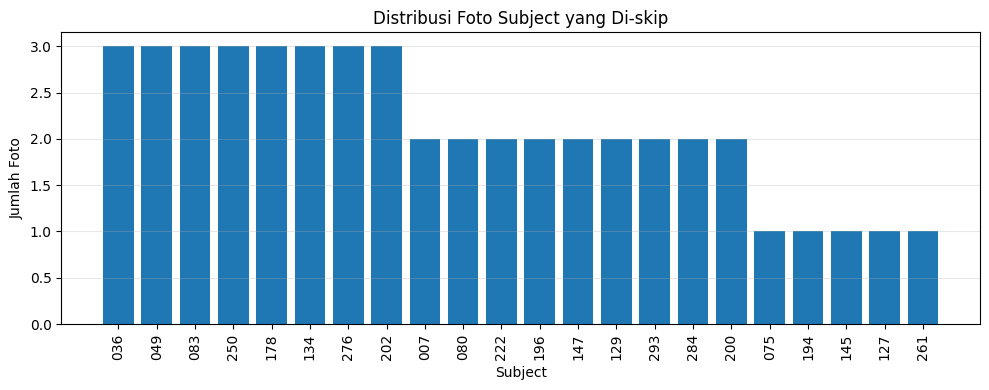

In [37]:
# =====================================================================
# BAGIAN 5D — ANALISIS SUBJECT YANG DI-SKIP (CALON IMPOSTOR)
# =====================================================================

from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Hitung jumlah gambar setiap subject
subject_counter = Counter(y)

# Ambil hanya subject yang di-skip
rows = []
for subj in skipped_subjects:
    rows.append({
        "Subject": subj,
        "Jumlah Foto": subject_counter[subj]
    })

df_skipped = (
    pd.DataFrame(rows)
      .sort_values("Jumlah Foto", ascending=False)
      .reset_index(drop=True)
)

print("="*60)
print("SUBJECT YANG DI-SKIP (<4 FOTO)")
print("="*60)

display(df_skipped)

print(f"\nJumlah subject : {len(df_skipped)}")
print(f"Total foto     : {df_skipped['Jumlah Foto'].sum()}")

print("\nDistribusi jumlah foto:")
print(df_skipped["Jumlah Foto"].value_counts().sort_index())

# Visualisasi
plt.figure(figsize=(10,4))
plt.bar(df_skipped["Subject"].astype(str),
        df_skipped["Jumlah Foto"])

plt.xlabel("Subject")
plt.ylabel("Jumlah Foto")
plt.title("Distribusi Foto Subject yang Di-skip")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


[6] Menjalankan PCA langsung pada Vektor L2-Norm (Bebas Distorsi)...
  Menganalisis matriks fitur (Full SVD)...
  Memotong komponen untuk varians 95% (Instant Slicing)...

  PCA 99% variance:
    Komponen : 582 (dari 1788 dim)
    Variance : 0.9901
    Reduksi  : 1788 → 582 (67.4%)

  PCA 95% variance:
    Komponen : 440 (dari 1788 dim)
    Variance : 0.9503
    Reduksi  : 1788 → 440 (75.4%)

  Selisih komponen: 142 dim lebih sedikit dengan PCA 95%
  Speed gain      : ~24.4% lebih cepat saat inference

  Quick separability check...

  Separability Index (d'):
    PCA 99% : 4.2242  | pos_mean=0.5409  neg_mean=0.0052
    PCA 95% : 4.2624  | pos_mean=0.5598  neg_mean=0.0056

  ✅ Pilih PCA 95% — separability hampir sama, komputasi jauh lebih ringan!

  PCA final terpilih: 440 komponen (95% variance)


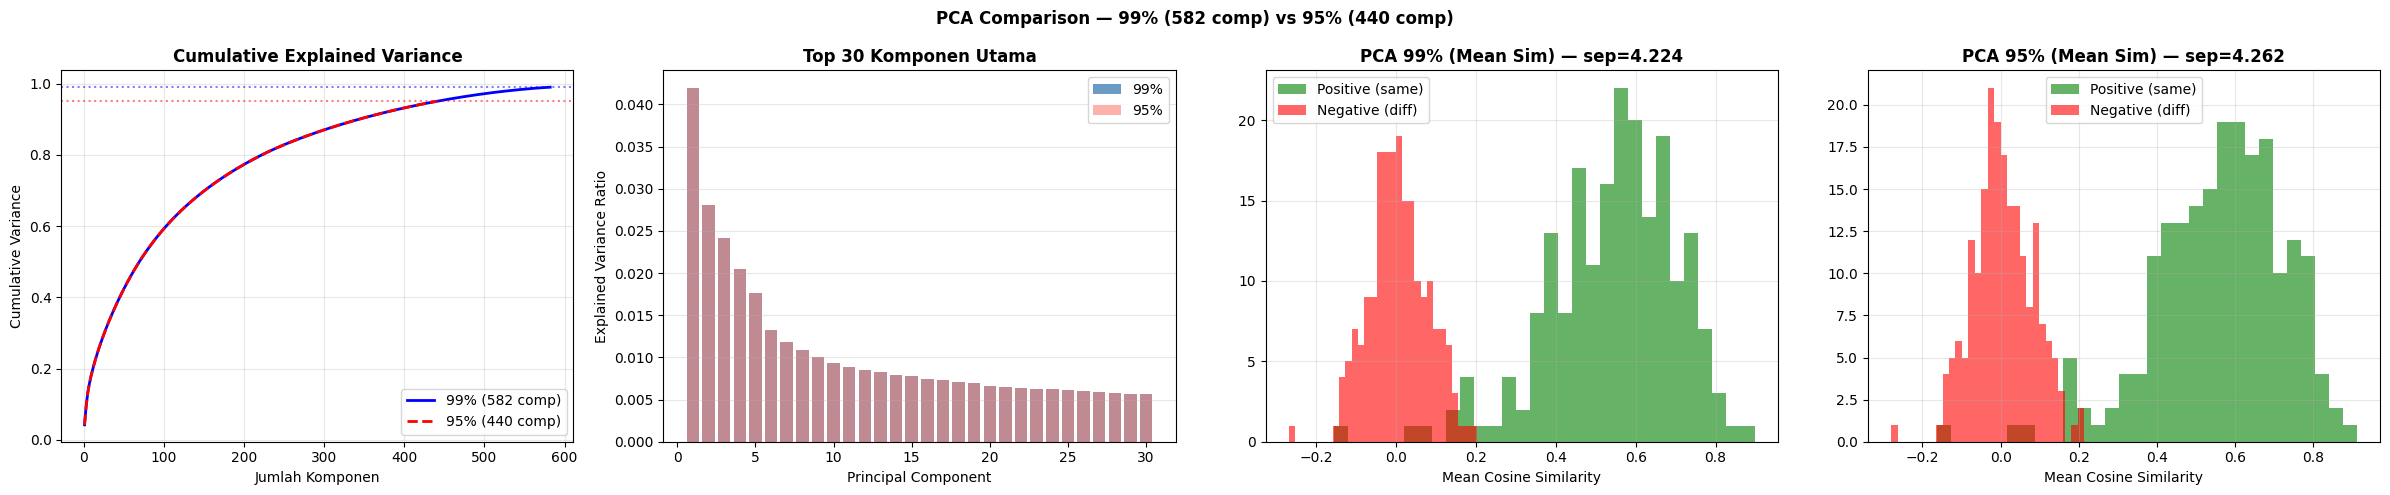


✓ PCA siap — 440 komponen dipakai untuk Cell berikutnya.


In [30]:
# =====================================================================
# BAGIAN 6 — NORMALISASI & PCA 
# =====================================================================

print('\n[6] Menjalankan PCA langsung pada Vektor L2-Norm (Bebas Distorsi)...')

X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

# 1. Cukup FIT SATU KALI pada target tertinggi (0.99) memakai solver 'full'
print('  Menganalisis matriks fitur (Full SVD)...')
pca_99 = PCA(n_components=0.99, svd_solver='full', whiten=False, random_state=42)

X_train_pca_99 = pca_99.fit_transform(X_train_sc)
X_test_pca_99  = pca_99.transform(X_test_sc)

# 2. Hitung secara matematis berapa komponen yang dibutuhkan untuk mencapai 95%
cumsum_variance = np.cumsum(pca_99.explained_variance_ratio_)
n_comp_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_comp_99 = pca_99.n_components_

# 3. Buat objek pca_95 tiruan dan lakukan SLICING instan (0 detik, hemat CPU!)
print('  Memotong komponen untuk varians 95% (Instant Slicing)...')
X_train_pca_95 = X_train_pca_99[:, :n_comp_95]
X_test_pca_95  = X_test_pca_99[:, :n_comp_95]

#import sys
sys.path.insert(0, r"D:\xampp\htdocs\palmprint-backend\palmprint-ml")
from app.target_pca import TargetPCA

pca_95 = TargetPCA(n_comp_95, pca_99.explained_variance_ratio_[:n_comp_95])

# Ambil template dari X_train_pca berdasarkan posisi awal (sebelum augmented)
# X_train = vstack([X_template, X_aug]), jadi template ada di index 0 s/d n_template-1
n_template = len(X_template)
X_train_pca_99_template = X_train_pca_99[:n_template]
X_train_pca_95_template = X_train_pca_95[:n_template]

print(f'\n  PCA 99% variance:')
print(f'    Komponen : {n_comp_99} (dari {X_train.shape[1]} dim)')
print(f'    Variance : {np.sum(pca_99.explained_variance_ratio_):.4f}')
print(f'    Reduksi  : {X_train.shape[1]} → {n_comp_99} ({(1 - n_comp_99/X_train.shape[1])*100:.1f}%)')

print(f'\n  PCA 95% variance:')
print(f'    Komponen : {n_comp_95} (dari {X_train.shape[1]} dim)')
print(f'    Variance : {np.sum(pca_95.explained_variance_ratio_):.4f}')
print(f'    Reduksi  : {X_train.shape[1]} → {n_comp_95} ({(1 - n_comp_95/X_train.shape[1])*100:.1f}%)')

print(f'\n  Selisih komponen: {n_comp_99 - n_comp_95} dim lebih sedikit dengan PCA 95%')
print(f'  Speed gain      : ~{((n_comp_99 - n_comp_95) / n_comp_99 * 100):.1f}% lebih cepat saat inference')


# ── Quick separability check untuk kedua PCA ──
print('\n  Quick separability check...')

def quick_separability_fixed(X_test_pca, X_template_pca, y_template, y_test, n_sample=200):
    np.random.seed(42)
    idx = np.random.choice(len(X_test_pca), min(n_sample, len(X_test_pca)), replace=False)

    pos_sims, neg_sims = [], []
    for i in idx:
        yt = y_test[i]
        xt = X_test_pca[i].reshape(1, -1)

        same_idx = np.where(y_template == yt)[0]
        tmpl_pca = X_template_pca[same_idx]
        pos_sims.append(np.mean(cosine_similarity(xt, tmpl_pca)[0]))

        diff_subj = [s for s in np.unique(y_template) if s != yt]
        rand_subj = np.random.choice(diff_subj)
        diff_idx  = np.where(y_template == rand_subj)[0][:3]
        neg_pca   = X_template_pca[diff_idx]
        neg_sims.append(np.mean(cosine_similarity(xt, neg_pca)[0]))

    pos = np.array(pos_sims)
    neg = np.array(neg_sims)
    sep = (pos.mean() - neg.mean()) / np.maximum(np.sqrt(0.5 * (pos.var() + neg.var())), 1e-8)
    return pos, neg, sep

pos_99, neg_99, sep_99 = quick_separability_fixed(X_test_pca_99, X_train_pca_99_template, y_template, y_test)
pos_95, neg_95, sep_95 = quick_separability_fixed(X_test_pca_95, X_train_pca_95_template, y_template, y_test)

print(f'\n  Separability Index (d\'):')
print(f'    PCA 99% : {sep_99:.4f}  | pos_mean={pos_99.mean():.4f}  neg_mean={neg_99.mean():.4f}')
print(f'    PCA 95% : {sep_95:.4f}  | pos_mean={pos_95.mean():.4f}  neg_mean={neg_95.mean():.4f}')

# ── Pilih PCA berdasarkan separability ──
if sep_95 >= sep_99 * 0.98:
    print(f'\n  ✅ Pilih PCA 95% — separability hampir sama, komputasi jauh lebih ringan!')
    # Gunakan slicing 95% untuk set final
    X_train_pca = X_train_pca_95
    X_test_pca  = X_test_pca_95
    final_components = n_comp_95
    Config.PCA_VARIANCE = 0.95
else:
    print(f'\n  ✅ Pilih PCA 99% — separability lebih presisi, mempertahankan informasi mikro!')
    X_train_pca = X_train_pca_99
    X_test_pca  = X_test_pca_99
    final_components = n_comp_99
    Config.PCA_VARIANCE = 0.99

print(f'\n  PCA final terpilih: {final_components} komponen ({Config.PCA_VARIANCE*100:.0f}% variance)')


# ── Visualisasi perbandingan ──
# (Ganti referensi plotting agar aman membaca dummy object pca_95)
cumsum_99 = np.cumsum(pca_99.explained_variance_ratio_)
cumsum_95 = cumsum_99[:n_comp_95]

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle(f'PCA Comparison — 99% ({n_comp_99} comp) vs 95% ({n_comp_95} comp)', fontsize=12, fontweight='bold')

axes[0].plot(range(1, n_comp_99 + 1), cumsum_99, 'b-', lw=2, label=f'99% ({n_comp_99} comp)')
axes[0].plot(range(1, n_comp_95 + 1), cumsum_95, 'r--', lw=2, label=f'95% ({n_comp_95} comp)')
axes[0].axhline(0.99, color='blue', ls=':', alpha=0.5)
axes[0].axhline(0.95, color='red',  ls=':', alpha=0.5)
axes[0].set_xlabel('Jumlah Komponen'); axes[0].set_ylabel('Cumulative Variance')
axes[0].set_title('Cumulative Explained Variance', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].bar(range(1, min(31, n_comp_99+1)), pca_99.explained_variance_ratio_[:30], color='steelblue', alpha=0.8, label='99%')
axes[1].bar(range(1, min(31, n_comp_95+1)), pca_95.explained_variance_ratio_[:30], color='salmon', alpha=0.6, label='95%')
axes[1].set_xlabel('Principal Component'); axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('Top 30 Komponen Utama', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

axes[2].hist(pos_99, bins=30, alpha=0.6, color='green', label=f'Positive (same)')
axes[2].hist(neg_99, bins=30, alpha=0.6, color='red',   label=f'Negative (diff)')
axes[2].set_title(f'PCA 99% (Mean Sim) — sep={sep_99:.3f}', fontweight='bold')
axes[2].set_xlabel('Mean Cosine Similarity'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

axes[3].hist(pos_95, bins=30, alpha=0.6, color='green', label=f'Positive (same)')
axes[3].hist(neg_95, bins=30, alpha=0.6, color='red',   label=f'Negative (diff)')
axes[3].set_title(f'PCA 95% (Mean Sim) — sep={sep_95:.3f}', fontweight='bold')
axes[3].set_xlabel('Mean Cosine Similarity'); axes[3].legend(); axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n✓ PCA siap — {final_components} komponen dipakai untuk Cell berikutnya.')


[7] Menyiapkan positive & negative pairs dengan Direct Label Matching...
  Positive pairs : 1736
  Negative pairs : 1736
  Positive sim   : mean=0.3572, std=0.1080
  Negative sim   : mean=-0.0019, std=0.0586
  Separability   : 4.1334

  Sweeping threshold 0.001–0.400 (High Resolution)...

  ✓ Threshold optimal (EER point):
    Threshold : 0.1070
    FAR       : 0.0323
    FRR       : 0.0317
    EER       : 0.0320
    Accuracy  : 0.9680
    F1        : 0.9680

  ✓ Threshold alternatif (F1 terbaik):
    Threshold : 0.1200
    FAR       : 0.0196
    FRR       : 0.0328
    F1        : 0.9736
    Accuracy  : 0.9738


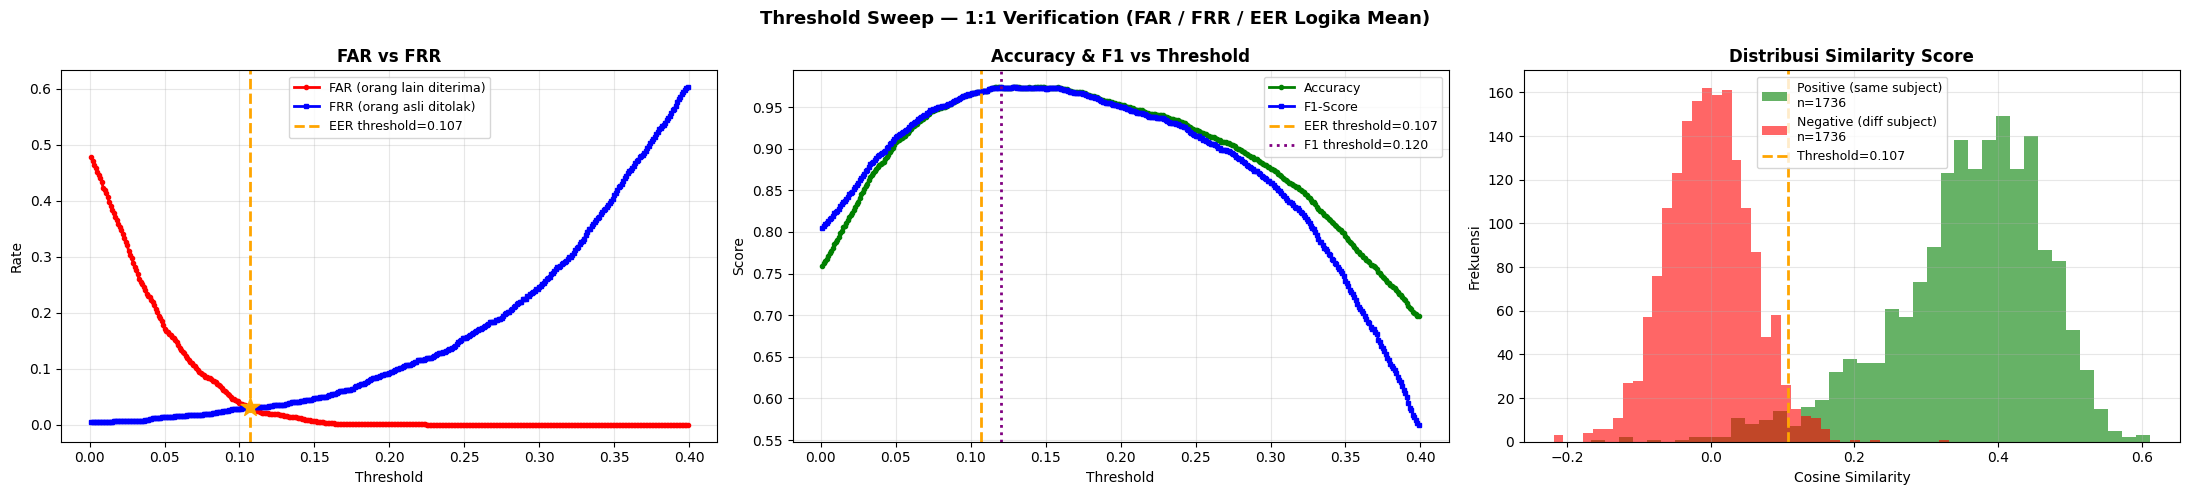

In [31]:
# =====================================================================
# BAGIAN 7 — SWEEP THRESHOLD (PERBAIKAN TOTAL: DIRECT LABEL MATCHING)
# =====================================================================

print('\n[7] Menyiapkan positive & negative pairs dengan Direct Label Matching...')
 
np.random.seed(42)

positive_scores = []  
negative_scores = []  

# Tentukan pool data latih berdasarkan PCA terpilih
X_train_pool = X_train_pca_95 if Config.PCA_VARIANCE == 0.95 else X_train_pca_99

# Ambil subset data template asli (NON-AUGMENTED) langsung dari X_train_pool
# Kita asumsikan kamu punya variabel penanda mana yang data original (misal lewat label atau kondisi split)
# JIKA tidak ada, kita bisa langsung cari ke seluruh data TRAIN yang labelnya sama, 
# karena data augmented dari subjek yang sama justru bagus untuk memperkuat nilai mean!

for i, (x_test, y_t) in enumerate(zip(X_test_pca, y_test)):

    # ── Positive pair: Ambil semua data latih (termasuk yang original) milik subjek y_t ──
    # Cari langsung ke y_train (label pasangan dari X_train)
    same_train_idx = np.where(y_train == y_t)[0] 
    
    if len(same_train_idx) > 0:
        templates_pca = X_train_pool[same_train_idx]
        sims_positive = cosine_similarity([x_test], templates_pca)[0]
        positive_scores.append(np.mean(sims_positive))
    else:
        # Fallback aman jika label tidak ditemukan
        positive_scores.append(0.0)

    # ── Negative pair: Ambil data dari subjek lain acak langsung dari y_train ──
    diff_subjects  = [s for s in np.unique(y_train) if s != y_t]
    rand_subject   = np.random.choice(diff_subjects)
    diff_train_idx = np.where(y_train == rand_subject)[0]
    
    if len(diff_train_idx) > 0:
        neg_templ_pca = X_train_pool[diff_train_idx]
        sims_negative = cosine_similarity([x_test], neg_templ_pca)[0]
        negative_scores.append(np.mean(sims_negative))
    else:
        negative_scores.append(0.0)

positive_scores = np.array(positive_scores)
negative_scores = np.array(negative_scores)

print(f'  Positive pairs : {len(positive_scores)}')
print(f'  Negative pairs : {len(negative_scores)}')
print(f'  Positive sim   : mean={positive_scores.mean():.4f}, std={positive_scores.std():.4f}')
print(f'  Negative sim   : mean={negative_scores.mean():.4f}, std={negative_scores.std():.4f}')

# Rekalkulasi index d-prime
sep_index = (positive_scores.mean() - negative_scores.mean()) / np.maximum(np.sqrt(0.5 * (positive_scores.var() + negative_scores.var())), 1e-8)
print(f'  Separability   : {sep_index:.4f}')

# ── Sweep threshold rapat di area desimal bawah ──
print('\n  Sweeping threshold 0.001–0.400 (High Resolution)...')

# Menggunakan step 0.001 agar pencarian EER lebih sensitif dan presisi
thresholds_sweep = np.arange(0.001, 0.400, 0.001)
results_sweep    = []

for th in thresholds_sweep:
    tp = np.sum(positive_scores >= th)  
    fn = np.sum(positive_scores <  th)  
    fp = np.sum(negative_scores >= th)  
    tn = np.sum(negative_scores <  th)  

    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0  
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0.0  
    acc = (tp + tn) / (tp + tn + fp + fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    results_sweep.append({
        'threshold': th,
        'far'      : far,
        'frr'      : frr,
        'eer_diff' : abs(far - frr),
        'accuracy' : acc,
        'f1'       : f1,
        'precision': precision,
        'recall'   : recall,
    })

# 🔥 Ambil ulang Threshold Optimal berdasarkan resolusi tinggi
best_eer = min(results_sweep, key=lambda r: r['eer_diff'])
best_f1  = max(results_sweep, key=lambda r: r['f1'])
THRESHOLD_OPTIMAL = best_eer['threshold']

print(f'\n  ✓ Threshold optimal (EER point):')
print(f'    Threshold : {best_eer["threshold"]:.4f}')
print(f'    FAR       : {best_eer["far"]:.4f}')
print(f'    FRR       : {best_eer["frr"]:.4f}')
print(f'    EER       : {(best_eer["far"] + best_eer["frr"]) / 2:.4f}')
print(f'    Accuracy  : {best_eer["accuracy"]:.4f}')
print(f'    F1        : {best_eer["f1"]:.4f}')

print(f'\n  ✓ Threshold alternatif (F1 terbaik):')
print(f'    Threshold : {best_f1["threshold"]:.4f}')
print(f'    FAR       : {best_f1["far"]:.4f}')
print(f'    FRR       : {best_f1["frr"]:.4f}')
print(f'    F1        : {best_f1["f1"]:.4f}')
print(f'    Accuracy  : {best_f1["accuracy"]:.4f}')


# ── Visualisasi ──
ths  = [r['threshold'] for r in results_sweep]
fars = [r['far']       for r in results_sweep]
frrs = [r['frr']       for r in results_sweep]
accs = [r['accuracy']  for r in results_sweep]
f1s  = [r['f1']        for r in results_sweep]

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Threshold Sweep — 1:1 Verification (FAR / FRR / EER Logika Mean)', fontsize=13, fontweight='bold')

# ── Kiri: FAR vs FRR ──
axes[0].plot(ths, fars, 'r-o',  ms=3, lw=2, label='FAR (orang lain diterima)')
axes[0].plot(ths, frrs, 'b-s',  ms=3, lw=2, label='FRR (orang asli ditolak)')
axes[0].axvline(THRESHOLD_OPTIMAL, color='orange', ls='--', lw=2, label=f'EER threshold={THRESHOLD_OPTIMAL:.3f}')
axes[0].scatter([best_eer['threshold']], [best_eer['far']], color='orange', s=200, zorder=5, marker='*')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Rate')
axes[0].set_title('FAR vs FRR', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# ── Tengah: Accuracy & F1 ──
axes[1].plot(ths, accs, 'g-o', ms=3, lw=2, label='Accuracy')
axes[1].plot(ths, f1s,  'b-s', ms=3, lw=2, label='F1-Score')
axes[1].axvline(THRESHOLD_OPTIMAL, color='orange', ls='--', lw=2, label=f'EER threshold={THRESHOLD_OPTIMAL:.3f}')
axes[1].axvline(best_f1['threshold'], color='purple', ls=':', lw=2, label=f'F1 threshold={best_f1["threshold"]:.3f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('Accuracy & F1 vs Threshold', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# ── Kanan: Distribusi similarity score ──
axes[2].hist(positive_scores, bins=40, alpha=0.6, color='green', label=f'Positive (same subject)\nn={len(positive_scores)}')
axes[2].hist(negative_scores, bins=40, alpha=0.6, color='red', label=f'Negative (diff subject)\nn={len(negative_scores)}')
axes[2].axvline(THRESHOLD_OPTIMAL, color='orange', ls='--', lw=2, label=f'Threshold={THRESHOLD_OPTIMAL:.3f}')
axes[2].set_xlabel('Cosine Similarity'); axes[2].set_ylabel('Frekuensi')
axes[2].set_title('Distribusi Similarity Score', fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


[7B] Membandingkan skenario gallery & aggregasi skor...

Skenario                          Titik EER                      FAR<=5%                       FAR<=2%                       FAR<=1%            
                           Thr     FAR     FRR     Acc   Thr     FAR     FRR     Acc   Thr     FAR     FRR     Acc   Thr     FAR     FRR     Acc
------------------------------------------------------------------------------------------------------------------------------------------------
Raw 3-foto · mean        0.152   3.23%   3.28%  96.75% 0.133   4.95%   3.00%  96.03% 0.175   1.90%   3.97%  97.06% 0.198   0.92%   4.32%  97.38%
Raw 3-foto · max         0.209   2.88%   2.94%  97.09% 0.181   4.90%   2.65%  96.23% 0.221   1.90%   3.00%  97.55% 0.254   0.86%   3.46%  97.84%
Augmented 21x · mean     0.107   3.23%   3.17%  96.80% 0.094   4.90%   2.71%  96.20% 0.120   1.96%   3.28%  97.38% 0.143   0.98%   4.32%  97.35%
Augmented 21x · max      0.249   2.53%   2.59%  97.44% 0.224   4.84%   2

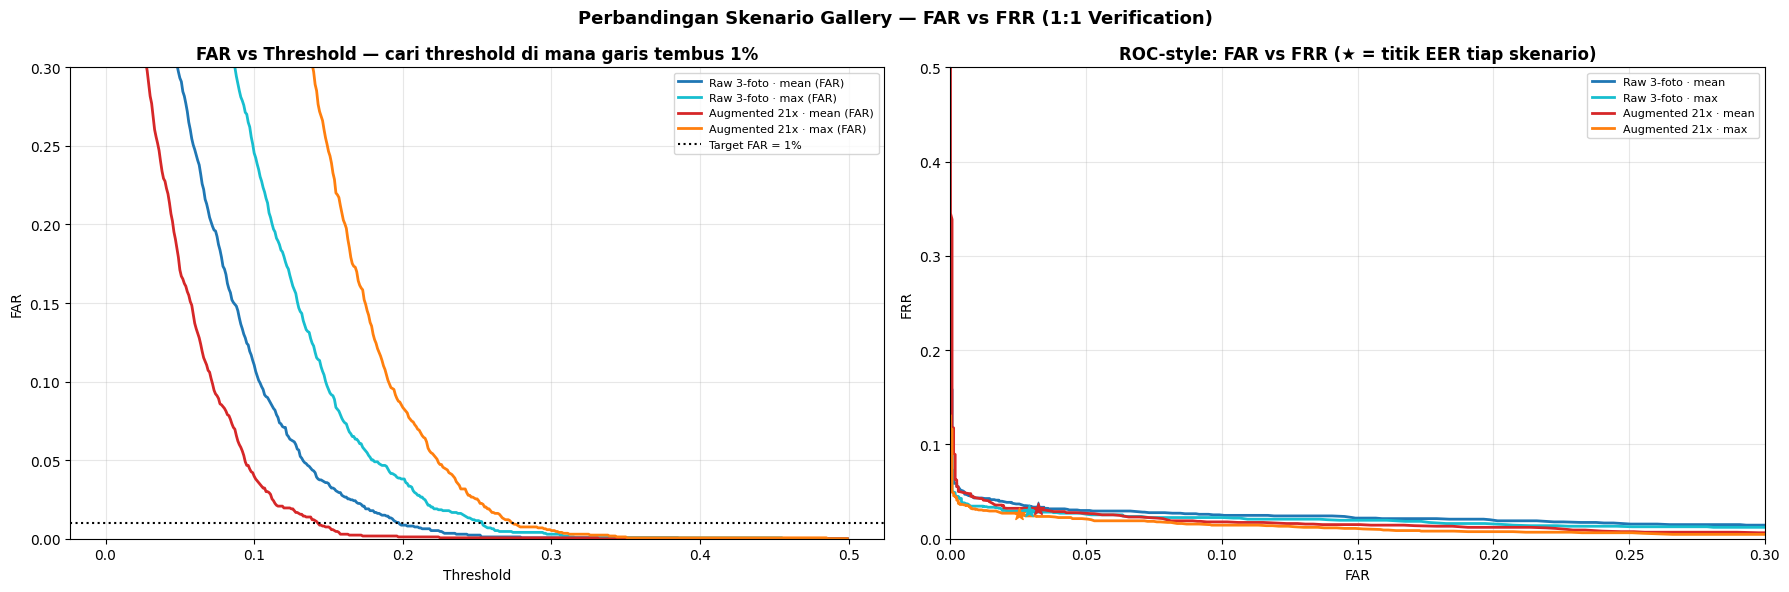


✓ Grafik perbandingan disimpan: results/perbandingan_gallery_scenario.png

→ Pilih skenario dengan FRR PALING RENDAH pada kolom "Titik FAR<=1%" di tabel di atas
  sebagai skema gallery + threshold final untuk produksi (Cell 9 — Simpan Model).


In [32]:
# =====================================================================
# BAGIAN 7B — PERBANDINGAN GALLERY RAW vs AUGMENTED, MEAN vs MAX
# Tujuan: menentukan skema gallery + threshold produksi yang PALING AMAN
# =====================================================================

print('\n[7B] Membandingkan skenario gallery & aggregasi skor...')

# ── Siapkan dua jenis gallery (keduanya di ruang PCA yang sama) ──
n_template = len(X_template)

X_gallery_raw   = X_train_pca[:n_template]   # 3 vektor mentah / subject (kondisi produksi: registrasi tanpa augmentasi)
y_gallery_raw   = y_train[:n_template]        # == y_template

X_gallery_aug   = X_train_pca                 # 3 + 18 augmented / subject (kondisi saat ini di notebook)
y_gallery_aug   = y_train


def compute_pair_scores(X_test_pca, y_test, X_gallery_pca, y_gallery, agg='mean', seed=42):
    """
    Simulasi verifikasi 1:1 yang sebenarnya:
    - Positive : query user X dibandingkan ke gallery user X sendiri (klaim benar)
    - Negative : query user X "mencoba klaim" sebagai user lain acak (skenario User B → akun User A)
    """
    rng = np.random.RandomState(seed)
    pos_scores, neg_scores = [], []
    unique_gallery_subjects = np.unique(y_gallery)

    for x_q, y_q in zip(X_test_pca, y_test):
        x_q = x_q.reshape(1, -1)

        # Positive pair
        same_idx = np.where(y_gallery == y_q)[0]
        if len(same_idx) > 0:
            sims = cosine_similarity(x_q, X_gallery_pca[same_idx])[0]
            pos_scores.append(sims.max() if agg == 'max' else sims.mean())

        # Negative pair — klaim acak ke subject lain (bukan dirinya)
        diff_subjects = unique_gallery_subjects[unique_gallery_subjects != y_q]
        rand_subject = rng.choice(diff_subjects)
        diff_idx = np.where(y_gallery == rand_subject)[0]
        if len(diff_idx) > 0:
            sims = cosine_similarity(x_q, X_gallery_pca[diff_idx])[0]
            neg_scores.append(sims.max() if agg == 'max' else sims.mean())

    return np.array(pos_scores), np.array(neg_scores)


def sweep_far_frr(pos, neg, th_range):
    rows = []
    for th in th_range:
        tp = np.sum(pos >= th); fn = np.sum(pos < th)
        fp = np.sum(neg >= th); tn = np.sum(neg < th)
        far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        frr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
        acc = (tp + tn) / (tp + tn + fp + fn)
        rows.append({'threshold': th, 'far': far, 'frr': frr, 'accuracy': acc})
    return rows


def find_eer_point(rows):
    return min(rows, key=lambda r: abs(r['far'] - r['frr']))


def find_threshold_for_far(rows, far_target):
    for r in rows:
        if r['far'] <= far_target:
            return r
    return None


# ── Jalankan 4 kombinasi skenario ──
scenarios = {
    'Raw 3-foto · mean'  : dict(gallery=(X_gallery_raw, y_gallery_raw), agg='mean'),
    'Raw 3-foto · max'   : dict(gallery=(X_gallery_raw, y_gallery_raw), agg='max'),
    'Augmented 21x · mean': dict(gallery=(X_gallery_aug, y_gallery_aug), agg='mean'),
    'Augmented 21x · max' : dict(gallery=(X_gallery_aug, y_gallery_aug), agg='max'),
}

th_range = np.arange(0.001, 0.500, 0.001)
results_scenario = {}

for name, cfg in scenarios.items():
    Xg, yg = cfg['gallery']
    pos, neg = compute_pair_scores(X_test_pca, y_test, Xg, yg, agg=cfg['agg'])
    rows = sweep_far_frr(pos, neg, th_range)
    far_targets = [0.05, 0.02, 0.01]
    results_scenario[name] = {
        'pos': pos, 'neg': neg, 'rows': rows,
        'eer_row': find_eer_point(rows),
        'far_rows': {ft: find_threshold_for_far(rows, ft) for ft in far_targets},
    }

def fmt_row(r):
    if r is None:
        return f"{'—':>6} {'—':>7} {'—':>7} {'—':>7}"
    return f"{r['threshold']:>6.3f} {r['far']*100:>6.2f}% {r['frr']*100:>6.2f}% {r['accuracy']*100:>6.2f}%"

far_targets = [0.05, 0.02, 0.01]
col_width = 30
header_targets = "".join([f"FAR<={int(ft*100)}%".center(col_width) for ft in far_targets])
print('\n' + '=' * (24 + 30 + len(far_targets) * col_width))
print(f"{'Skenario':<24}{'Titik EER'.center(30)}{header_targets}")
sub = f"{'':<24}" + f"{'Thr     FAR     FRR     Acc':>30}"
for _ in far_targets:
    sub += f"{'Thr     FAR     FRR     Acc':>30}"
print(sub)
print('-' * (24 + 30 + len(far_targets) * col_width))

for name, res in results_scenario.items():
    line = f"{name:<24}{fmt_row(res['eer_row']):>30}"
    for ft in far_targets:
        line += f"{fmt_row(res['far_rows'][ft]):>30}"
    print(line)
print('=' * (24 + 30 + len(far_targets) * col_width))
# ── Visualisasi FAR vs FRR overlay untuk 4 skenario ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Perbandingan Skenario Gallery — FAR vs FRR (1:1 Verification)', fontsize=13, fontweight='bold')

colors = {'Raw 3-foto · mean': 'tab:blue', 'Raw 3-foto · max': 'tab:cyan',
          'Augmented 21x · mean': 'tab:red', 'Augmented 21x · max': 'tab:orange'}

for name, res in results_scenario.items():
    ths  = [r['threshold'] for r in res['rows']]
    fars = [r['far'] for r in res['rows']]
    frrs = [r['frr'] for r in res['rows']]
    axes[0].plot(ths, fars, color=colors[name], lw=2, label=f'{name} (FAR)')
    axes[1].plot(fars, frrs, color=colors[name], lw=2, label=name)
    axes[1].scatter([res['eer_row']['far']], [res['eer_row']['frr']], color=colors[name], s=80, zorder=5, marker='*')

axes[0].axhline(0.01, color='black', ls=':', lw=1.5, label='Target FAR = 1%')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('FAR')
axes[0].set_title('FAR vs Threshold — cari threshold di mana garis tembus 1%', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 0.3)

axes[1].set_xlabel('FAR'); axes[1].set_ylabel('FRR')
axes[1].set_title('ROC-style: FAR vs FRR (★ = titik EER tiap skenario)', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 0.3); axes[1].set_ylim(0, 0.5)

plt.tight_layout()
plt.savefig('results/perbandingan_gallery_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ Grafik perbandingan disimpan: results/perbandingan_gallery_scenario.png')
print('\n→ Pilih skenario dengan FRR PALING RENDAH pada kolom "Titik FAR<=1%" di tabel di atas')
print('  sebagai skema gallery + threshold final untuk produksi (Cell 9 — Simpan Model).')


In [41]:
# =====================================================================
# BAGIAN 7C-REVISED — IDENTIFICATION (1:N) THRESHOLD SWEEP YANG BENAR
# Query dibandingkan ke SEMUA subject di gallery (bukan cuma 1 impostor acak)
# Membandingkan skema agregasi: max, mean, top-k mean
# Serta gallery: raw 3-foto vs augmented 21x
# =====================================================================

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def aggregate_scores(sims, method):
    """sims: array similarity 1 query vs semua vector milik 1 subject."""
    if method == 'max':
        return np.max(sims)
    if method == 'mean':
        return np.mean(sims)
    if method.startswith('top'):
        k = int(method.replace('top', ''))
        k = min(k, len(sims))
        return np.mean(np.sort(sims)[-k:])
    raise ValueError(method)


def run_identification_1toN(X_test_pca, y_test, X_gallery, y_gallery, method='max'):
    """
    Identifikasi 1:N sungguhan:
    - Query dibandingkan ke SEMUA subject unik di gallery
    - Skor per subject = agregasi similarity (max / mean / top-k)
    - Prediksi = subject dengan skor tertinggi (argmax)
    """
    unique_subjects = np.unique(y_gallery)
    best_scores = []
    is_correct  = []

    for query_vec, true_label in zip(X_test_pca, y_test):
        query_vec = query_vec.reshape(1, -1)
        scores = []
        for subj in unique_subjects:
            idx = np.where(y_gallery == subj)[0]
            sims = cosine_similarity(query_vec, X_gallery[idx])[0]
            scores.append((subj, aggregate_scores(sims, method)))

        scores.sort(key=lambda x: x[1], reverse=True)
        pred_subject, best_score = scores[0]

        best_scores.append(best_score)
        is_correct.append(1 if pred_subject == true_label else 0)

    return np.array(best_scores), np.array(is_correct)


def sweep_identification_threshold(scores, correct, th_range):
    rows = []
    for th in th_range:
        accept = scores >= th
        TP = np.sum(accept & (correct == 1))
        FP = np.sum(accept & (correct == 0))
        FN = np.sum(~accept & (correct == 1))
        TN = np.sum(~accept & (correct == 0))

        far = FP / (FP + TN) if (FP + TN) > 0 else 0.0
        frr = FN / (FN + TP) if (FN + TP) > 0 else 0.0
        acc = (TP + TN) / (TP + TN + FP + FN)
        rows.append({'threshold': th, 'far': far, 'frr': frr, 'acc': acc})
    return rows


def find_eer(rows):
    return min(rows, key=lambda r: abs(r['far'] - r['frr']))


def find_for_far(rows, far_target):
    for r in rows:
        if r['far'] <= far_target:
            return r
    return None


# ── Jalankan untuk beberapa kombinasi gallery x metode agregasi ──
th_range = np.arange(0.30, 1.00, 0.001)
far_targets = [0.05, 0.02, 0.01]

configs = {
    'Raw 3-foto · max'    : (X_gallery_raw, y_gallery_raw, 'max'),
    'Raw 3-foto · top3'   : (X_gallery_raw, y_gallery_raw, 'top3'),
    'Augmented 21x · max' : (X_gallery_aug, y_gallery_aug, 'max'),
    'Augmented 21x · top3': (X_gallery_aug, y_gallery_aug, 'top3'),
    'Augmented 21x · top5': (X_gallery_aug, y_gallery_aug, 'top5'),
    'Augmented 21x · mean': (X_gallery_aug, y_gallery_aug, 'mean'),
}

print("\n[7C-Revised] Identifikasi 1:N — bandingkan skema gallery & agregasi...\n")

results_1toN = {}
for name, (Xg, yg, method) in configs.items():
    scores, correct = run_identification_1toN(X_test_pca, y_test, Xg, yg, method=method)
    rows = sweep_identification_threshold(scores, correct, th_range)
    results_1toN[name] = {
        'scores': scores, 'correct': correct, 'rows': rows,
        'eer': find_eer(rows),
        'far_rows': {ft: find_for_far(rows, ft) for ft in far_targets},
    }

def fmt(r):
    if r is None:
        return f"{'—':>7}{'—':>8}{'—':>8}{'—':>8}"
    return f"{r['threshold']:>7.3f}{r['far']*100:>7.2f}%{r['frr']*100:>7.2f}%{r['acc']*100:>7.2f}%"

col = 32
header = "".join([f"FAR<={int(ft*100)}%".center(col) for ft in far_targets])
print("=" * (24 + col + len(far_targets) * col))
print(f"{'Skenario':<24}{'Titik EER'.center(col)}{header}")
print("=" * (24 + col + len(far_targets) * col))
for name, res in results_1toN.items():
    line = f"{name:<24}{fmt(res['eer']):>{col}}"
    for ft in far_targets:
        line += f"{fmt(res['far_rows'][ft]):>{col}}"
    print(line)
print("=" * (24 + col + len(far_targets) * col))
print("\n→ Pilih baris dengan FRR paling rendah di kolom FAR<=1% sebagai threshold PRODUKSI 1:N yang baru.")


[7C-Revised] Identifikasi 1:N — bandingkan skema gallery & agregasi...

Skenario                           Titik EER                        FAR<=5%                         FAR<=2%                         FAR<=1%             
Raw 3-foto · max           0.430   5.63%   5.65%  94.35%   0.446   4.23%   6.67%  93.43%   0.456   1.41%   7.51%  92.74%   0.608   0.00%  26.85%  74.25%
Raw 3-foto · top3          0.349   6.98%   7.45%  92.57%   0.351   4.65%   7.58%  92.57%   0.405   1.16%  13.88%  86.75%   0.415   0.00%  15.09%  85.66%
Augmented 21x · max        0.452   6.45%   6.69%  93.32%   0.461   4.84%   7.17%  92.91%   0.501   1.61%   9.98%  90.32%   0.612   0.00%  27.48%  73.50%
Augmented 21x · top3       0.427   8.06%   7.23%  92.74%   0.435   4.84%   8.12%  91.99%   0.455   1.61%   9.92%  90.38%   0.609   0.00%  38.11%  63.25%
Augmented 21x · top5       0.400   7.46%   7.79%  92.22%   0.411   4.48%   9.11%  91.07%   0.438   1.49%  11.80%  88.59%   0.587   0.00%  43.80%  57.89%
Augmented

In [48]:
# =====================================================================
# BAGIAN 7E — OPEN-SET IMPOSTOR TEST (Data yang BENAR-BENAR tidak terdaftar)
# Pakai 22 subject yang di-skip di Cell 5 (tidak pernah masuk gallery)
# Threshold diambil per-metode dari hasil 7C-Revised (results_1toN),
# bukan hardcoded satu set untuk semua metode.
# =====================================================================

print("\n[7E] Menguji FAR dengan impostor sungguhan (never enrolled)...")

impostor_mask = np.isin(y, skipped_subjects)
X_impostor = X[impostor_mask]
y_impostor = np.array(y)[impostor_mask]

print(f"  Total sampel impostor open-set : {len(X_impostor)} (dari {len(skipped_subjects)} subject)")

# Proyeksikan ke ruang PCA yang SAMA dengan gallery (ikuti PCA final yang terpilih di Bagian 6)
if Config.PCA_VARIANCE == 0.95:
    X_impostor_pca = pca_99.transform(X_impostor)[:, :n_comp_95]
else:
    X_impostor_pca = pca_99.transform(X_impostor)

def openset_scan(X_query_pca, X_gallery, y_gallery, method='max'):
    """Semua sampel di sini SEHARUSNYA ditolak (bukan siapa-siapa di gallery)."""
    unique_subjects = np.unique(y_gallery)
    best_scores = []
    for q in X_query_pca:
        q = q.reshape(1, -1)
        scores = []
        for subj in unique_subjects:
            idx = np.where(y_gallery == subj)[0]
            sims = cosine_similarity(q, X_gallery[idx])[0]
            scores.append(aggregate_scores(sims, method))
        best_scores.append(max(scores))
    return np.array(best_scores)

# ── Mapping metode -> nama config di results_1toN (pakai gallery augmented, sama dgn X_gallery_aug di sini) ──
method_to_config = {
    'max':  'Augmented 21x · max',
    'top3': 'Augmented 21x · top3',
    'top5': 'Augmented 21x · top5',
    'mean': 'Augmented 21x · mean',
}

far_targets_used = [0.05, 0.02, 0.01]  # sama seperti far_targets di 7C

for method in ['max', 'top3', 'top5', 'mean']:
    impostor_scores = openset_scan(X_impostor_pca, X_gallery_aug, y_gallery_aug, method=method)

    config_name = method_to_config[method]
    res = results_1toN[config_name]

    # Threshold titik EER
    th_eer = res['eer']['threshold']
    far_open_eer = np.mean(impostor_scores >= th_eer)
    print(f"  [{method:>5}] EER-threshold={th_eer:.3f} → FAR open-set = {far_open_eer*100:.2f}% "
          f"({np.sum(impostor_scores >= th_eer)}/{len(impostor_scores)} impostor lolos)")

    # Threshold per target FAR closed-set (5%, 2%, 1%)
    for ft in far_targets_used:
        row = res['far_rows'][ft]
        if row is None:
            print(f"  [{method:>5}] FAR<={int(ft*100)}% closed-set → tidak ditemukan threshold yang valid, dilewati")
            continue
        th_candidate = row['threshold']
        far_openset = np.mean(impostor_scores >= th_candidate)
        print(f"  [{method:>5}] threshold(FAR closed<={int(ft*100)}%)={th_candidate:.3f} → FAR open-set = {far_openset*100:.2f}% "
              f"({np.sum(impostor_scores >= th_candidate)}/{len(impostor_scores)} impostor lolos)")
    print()


[7E] Menguji FAR dengan impostor sungguhan (never enrolled)...
  Total sampel impostor open-set : 47 (dari 22 subject)
  [  max] EER-threshold=0.452 → FAR open-set = 4.26% (2/47 impostor lolos)
  [  max] threshold(FAR closed<=5%)=0.461 → FAR open-set = 4.26% (2/47 impostor lolos)
  [  max] threshold(FAR closed<=2%)=0.501 → FAR open-set = 2.13% (1/47 impostor lolos)
  [  max] threshold(FAR closed<=1%)=0.612 → FAR open-set = 0.00% (0/47 impostor lolos)

  [ top3] EER-threshold=0.427 → FAR open-set = 4.26% (2/47 impostor lolos)
  [ top3] threshold(FAR closed<=5%)=0.435 → FAR open-set = 4.26% (2/47 impostor lolos)
  [ top3] threshold(FAR closed<=2%)=0.455 → FAR open-set = 4.26% (2/47 impostor lolos)
  [ top3] threshold(FAR closed<=1%)=0.609 → FAR open-set = 0.00% (0/47 impostor lolos)

  [ top5] EER-threshold=0.400 → FAR open-set = 6.38% (3/47 impostor lolos)
  [ top5] threshold(FAR closed<=5%)=0.411 → FAR open-set = 6.38% (3/47 impostor lolos)
  [ top5] threshold(FAR closed<=2%)=0.438 → 


[7F] Menghitung margin untuk 3 populasi: genuine, closed-set impostor, open-set impostor...
  Genuine  (n=1736)  → margin mean=0.3598, std=0.1448
  Impostor (n=47) → margin mean=0.0280, std=0.0354

  ✓ Kombinasi terbaik (FAR open-set ≤ 1%, FRR paling rendah):
    {'sim_threshold': np.float64(0.4), 'margin_threshold': np.float64(0.17), 'frr': np.float64(0.11751152073732718), 'far_openset': np.float64(0.0)}


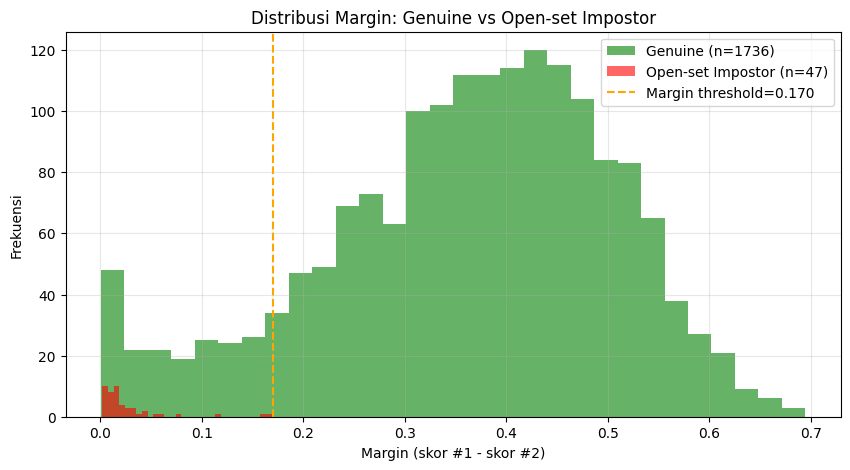

In [49]:
# =====================================================================
# BAGIAN 7F — MARGIN TUNING (lapisan kedua setelah threshold similarity)
# Margin = skor kandidat #1 - skor kandidat #2
# Tujuan: bedakan genuine match (margin besar, menonjol jelas)
#         vs impostor (margin kecil, skor antar kandidat mirip2 rata)
# =====================================================================

print("\n[7F] Menghitung margin untuk 3 populasi: genuine, closed-set impostor, open-set impostor...")

BEST_METHOD = 'top3'          # ganti sesuai hasil terbaik dari 7C-Revised
X_gallery_final = X_gallery_aug
y_gallery_final = y_gallery_aug

def compute_score_and_margin(query_vec, X_gallery, y_gallery, method):
    unique_subjects = np.unique(y_gallery)
    scores = []
    for subj in unique_subjects:
        idx = np.where(y_gallery == subj)[0]
        sims = cosine_similarity(query_vec.reshape(1, -1), X_gallery[idx])[0]
        scores.append((subj, aggregate_scores(sims, method)))
    scores.sort(key=lambda x: x[1], reverse=True)
    best_subj, best_score = scores[0]
    second_score = scores[1][1] if len(scores) > 1 else 0.0
    margin = best_score - second_score
    return best_subj, best_score, margin

# ── 1. Populasi GENUINE (query test milik user yang memang terdaftar) ──
genuine_margins, genuine_scores, genuine_correct = [], [], []
for query_vec, true_label in zip(X_test_pca, y_test):
    pred, score, margin = compute_score_and_margin(query_vec, X_gallery_final, y_gallery_final, BEST_METHOD)
    genuine_margins.append(margin)
    genuine_scores.append(score)
    genuine_correct.append(pred == true_label)

genuine_margins = np.array(genuine_margins)
genuine_scores  = np.array(genuine_scores)
genuine_correct = np.array(genuine_correct)

# ── 2. Populasi OPEN-SET IMPOSTOR (dari subject yang di-skip Cell 5) ──
impostor_margins, impostor_scores = [], []
for query_vec in X_impostor_pca:   # dari cell 7E sebelumnya
    _, score, margin = compute_score_and_margin(query_vec, X_gallery_final, y_gallery_final, BEST_METHOD)
    impostor_scores.append(score)
    impostor_margins.append(margin)

impostor_margins = np.array(impostor_margins)
impostor_scores  = np.array(impostor_scores)

print(f"  Genuine  (n={len(genuine_margins)})  → margin mean={genuine_margins.mean():.4f}, std={genuine_margins.std():.4f}")
print(f"  Impostor (n={len(impostor_margins)}) → margin mean={impostor_margins.mean():.4f}, std={impostor_margins.std():.4f}")

# ── 3. Sweep kombinasi threshold similarity + threshold margin ──
sim_thresholds    = np.arange(0.40, 0.90, 0.01)
margin_thresholds = np.arange(0.00, 0.20, 0.005)

best_combo = None
best_combo_frr = 1.0

for sim_th in sim_thresholds:
    for margin_th in margin_thresholds:
        # Genuine diterima jika lolos DUA syarat DAN benar-benar prediksi = label asli
        genuine_accept = (genuine_scores >= sim_th) & (genuine_margins >= margin_th) & genuine_correct
        frr = 1 - (np.sum(genuine_accept) / len(genuine_correct))

        # Impostor open-set diterima jika lolos DUA syarat (harusnya DITOLAK semua)
        impostor_accept = (impostor_scores >= sim_th) & (impostor_margins >= margin_th)
        far_openset = np.sum(impostor_accept) / len(impostor_scores)

        if far_openset <= 0.01 and frr < best_combo_frr:
            best_combo_frr = frr
            best_combo = {
                'sim_threshold': sim_th,
                'margin_threshold': margin_th,
                'frr': frr,
                'far_openset': far_openset,
            }

print("\n  ✓ Kombinasi terbaik (FAR open-set ≤ 1%, FRR paling rendah):")
print(f"    {best_combo}")

# ── Visualisasi distribusi margin ──
plt.figure(figsize=(10, 5))
plt.hist(genuine_margins, bins=30, alpha=0.6, color='green', label=f'Genuine (n={len(genuine_margins)})')
plt.hist(impostor_margins, bins=30, alpha=0.6, color='red', label=f'Open-set Impostor (n={len(impostor_margins)})')
if best_combo:
    plt.axvline(best_combo['margin_threshold'], color='orange', ls='--', label=f"Margin threshold={best_combo['margin_threshold']:.3f}")
plt.xlabel('Margin (skor #1 - skor #2)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Margin: Genuine vs Open-set Impostor')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
# =====================================================================
# BAGIAN 7G — LEAVE-SUBJECTS-OUT (LSO) CV: PERBESAR POOL IMPOSTOR
# Tujuan: pool impostor open-set asli cuma 47 sampel (22 subject) — terlalu
# kecil untuk klaim FAR yang solid secara statistik.
#
# Trik LSO: setiap query (1736 sampel) SUDAH dibandingkan ke SEMUA subject
# gallery di Cell 7C-Revised. Skor terbaik selain subject aslinya sendiri
# ITU SAMA PERSIS dengan skor yang akan didapat kalau subject asli itu
# "dikeluarkan" dari gallery (leave-subject-out) — tanpa perlu load ulang
# gambar / hitung ulang cosine_similarity dari nol.
#
# Jadi: 1736 query × "subject aslinya dianggap tidak terdaftar" = 1736
# skenario impostor tambahan yang VALID secara statistik (bukan re-sampling
# buatan), digabung dengan 47 impostor open-set asli → pool jauh lebih besar.
# =====================================================================

print("\n[7G] Menjalankan Leave-Subjects-Out CV untuk memperbesar pool impostor...")


def run_identification_lso(X_query_pca, y_query, X_gallery, y_gallery, method='max'):
    """
    Sekali loop, dapat 3 hal sekaligus (tidak ada cosine_similarity yang dihitung ulang):
      - genuine_scores      : skor query vs subject aslinya sendiri (bila terdaftar di gallery ini)
      - lso_impostor_scores : skor terbaik query vs SEMUA subject LAIN (bukan dirinya)
                               = simulasi "andai subject aslinya tidak pernah didaftarkan"
      - is_correct          : argmax closed-set (dengan dirinya tetap di gallery) == label asli
    """
    unique_subjects = np.unique(y_gallery)
    genuine_scores, lso_impostor_scores, is_correct = [], [], []

    for query_vec, true_label in zip(X_query_pca, y_query):
        query_vec = query_vec.reshape(1, -1)
        scores = {}
        for subj in unique_subjects:
            idx = np.where(y_gallery == subj)[0]
            sims = cosine_similarity(query_vec, X_gallery[idx])[0]
            scores[subj] = aggregate_scores(sims, method)

        genuine_scores.append(scores.get(true_label, np.nan))

        other_scores = [v for k, v in scores.items() if k != true_label]
        lso_impostor_scores.append(max(other_scores) if other_scores else np.nan)

        best_subj = max(scores, key=scores.get)
        is_correct.append(best_subj == true_label)

    return np.array(genuine_scores), np.array(lso_impostor_scores), np.array(is_correct)


def compute_openset_impostor_scores(X_query_pca, X_gallery, y_gallery, method='max'):
    """Sama seperti openset_scan di Cell 7E, dibuat generik untuk gallery raw maupun augmented."""
    unique_subjects = np.unique(y_gallery)
    best_scores = []
    for q in X_query_pca:
        q = q.reshape(1, -1)
        scores = []
        for subj in unique_subjects:
            idx = np.where(y_gallery == subj)[0]
            sims = cosine_similarity(q, X_gallery[idx])[0]
            scores.append(aggregate_scores(sims, method))
        best_scores.append(max(scores))
    return np.array(best_scores)


def wilson_ci_upper(k, n, conf=0.95):
    """Batas atas Wilson score interval untuk proporsi k/n (dipakai di Tahap 2 nanti,
    disiapkan di sini supaya bisa langsung dipakai tanpa tambahan import)."""
    if n == 0:
        return 1.0
    z = 1.959963984540054  # z-score utk 95% CI dua sisi
    phat = k / n
    denom = 1 + (z ** 2) / n
    centre = phat + (z ** 2) / (2 * n)
    margin = z * np.sqrt((phat * (1 - phat) / n) + (z ** 2) / (4 * n ** 2))
    return min((centre + margin) / denom, 1.0)


# ── Jalankan LSO-CV untuk semua kombinasi gallery x agregasi yang sama seperti Cell 7C-Revised ──
lso_results = {}

for name, (Xg, yg, method) in configs.items():
    genuine, lso_impostor, correct = run_identification_lso(X_test_pca, y_test, Xg, yg, method=method)
    openset = compute_openset_impostor_scores(X_impostor_pca, Xg, yg, method=method)

    combined_impostor = np.concatenate([lso_impostor, openset])

    lso_results[name] = {
        'genuine_scores'      : genuine,
        'lso_impostor_scores' : lso_impostor,
        'openset_scores'      : openset,
        'combined_impostor'   : combined_impostor,
        'is_correct'          : correct,
    }

    print(f"  [{name:<22}] pool impostor: {len(openset):>4} (open-set asli) "
          f"+ {len(lso_impostor):>4} (LSO) = {len(combined_impostor):>4} total "
          f"(naik {len(combined_impostor)/len(openset):.1f}x)")


# ── Bandingkan FAR: hanya pakai 47 impostor asli vs pool gabungan (LSO + asli) ──
# Threshold yang dipakai untuk perbandingan = threshold FAR<=1% closed-set dari Cell 7C-Revised (results_1toN)
print("\n" + "=" * 118)
print(f"{'Skenario':<24}{'Threshold':>11}{'FAR (47 asli saja)':>22}{'FAR (gabungan)':>18}"
      f"{'n (gabungan)':>14}{'95% CI upper (gabungan)':>26}")
print("-" * 118)

for name in configs:
    th = results_1toN[name]['far_rows'][0.01]
    if th is None:
        print(f"{name:<24}{'—':>11}{'—':>22}{'—':>18}{'—':>14}{'—':>26}")
        continue
    th = th['threshold']

    openset = lso_results[name]['openset_scores']
    combined = lso_results[name]['combined_impostor']

    far_openset_only = np.mean(openset >= th)
    k_combined = int(np.sum(combined >= th))
    n_combined = len(combined)
    far_combined = k_combined / n_combined
    ci_upper = wilson_ci_upper(k_combined, n_combined)

    print(f"{name:<24}{th:>11.3f}{far_openset_only*100:>21.2f}%{far_combined*100:>17.2f}%"
          f"{n_combined:>14}{ci_upper*100:>25.2f}%")

print("=" * 118)
print("\n→ Kolom 'FAR (47 asli saja)' rentan sample-noise (n kecil, satu impostor lolos = ±2%).")
print("  Kolom 'FAR (gabungan)' + '95% CI upper' jauh lebih dapat dipercaya sebagai estimasi FAR produksi.")
print("  Tahap 2 (selanjutnya): threshold produksi akan dioptimasi berdasarkan CI-upper ini, bukan titik estimasi mentah.")


# ── Visualisasi: distribusi genuine vs LSO-impostor vs open-set-impostor asli (skema terbaik sejauh ini) ──
best_preview = 'Augmented 21x · max'  # sekadar preview, skema final ditentukan di Tahap 2

fig, ax = plt.subplots(figsize=(10, 5))
r = lso_results[best_preview]
ax.hist(r['genuine_scores'], bins=40, alpha=0.55, color='green', density=True,
        label=f"Genuine (n={len(r['genuine_scores'])})")
ax.hist(r['lso_impostor_scores'], bins=40, alpha=0.55, color='orange', density=True,
        label=f"LSO-impostor (n={len(r['lso_impostor_scores'])})")
ax.hist(r['openset_scores'], bins=20, alpha=0.75, color='red', density=True,
        label=f"Open-set impostor asli (n={len(r['openset_scores'])})")
ax.set_title(f"Distribusi skor — {best_preview} (preview LSO-CV)", fontweight='bold')
ax.set_xlabel('Skor agregasi (cosine similarity)')
ax.set_ylabel('Densitas')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Pool impostor gabungan siap dipakai di Tahap 2 (variabel: lso_results[<nama_skenario>]['combined_impostor']).")



[7G] Menjalankan Leave-Subjects-Out CV untuk memperbesar pool impostor...


NameError: name 'configs' is not defined

In [34]:
# =====================================================================
# BAGIAN 9 — SIMPAN MODEL (REVISI: Threshold & Skema dari Cell 7B)
# =====================================================================

import os
import json
import joblib
import numpy as np

print('\n[9] Menyimpan model untuk production (Laravel / Flutter API)...')

os.makedirs(Config.MODELS_DIR, exist_ok=True)

# ── SKEMA TERPILIH (hasil diskusi Cell 7B): Augmented 21x · max · FAR<=1% ──
CHOSEN_SCENARIO    = 'Augmented 21x · max'
CHOSEN_FAR_TARGET  = 0.01

chosen   = results_scenario[CHOSEN_SCENARIO]
op_point = chosen['far_rows'][CHOSEN_FAR_TARGET]

THRESHOLD_PROD     = float(op_point['threshold'])
AGGREGATION        = 'max'
GALLERY_SCHEME     = 'augmented'
N_AUG_PER_TEMPLATE = 6   # HARUS sama dengan n_aug di augment_template_only() Cell 5

# ── Hitung precision/recall/F1 di titik operasi terpilih ──
pos = chosen['pos']; neg = chosen['neg']
tp = np.sum(pos >= THRESHOLD_PROD); fn = np.sum(pos < THRESHOLD_PROD)
fp = np.sum(neg >= THRESHOLD_PROD); tn = np.sum(neg < THRESHOLD_PROD)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1_chosen = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

# ✅ Simpan PCA dan Threshold
pca_final = pca_99
joblib.dump(pca_final, os.path.join(Config.MODELS_DIR, 'pca.pkl'))
joblib.dump(THRESHOLD_PROD, os.path.join(Config.MODELS_DIR, 'threshold.pkl'))

total_subjects = int(len(np.unique(np.concatenate([y_train, y_test]))))

best_config = {
    'hog_orient'    : int(getattr(Config, 'HOG_ORIENT', 9)),
    'hog_pixels'    : int(getattr(Config, 'HOG_PIXELS', 8)),
    'hog_cells'     : int(getattr(Config, 'HOG_CELLS', 2)),
    'pca_variance'  : float(Config.PCA_VARIANCE),
    'pca_n_comp'    : int(final_components),
    'pca_whiten'    : False,
    'use_dog'       : True,
    'gabor_ksize'   : int(Config.GABOR_KSIZE),
    'gabor_lambda'  : float(Config.GABOR_LAMBDA),

    # ── Skema verifikasi — WAJIB direplikasi sama persis di backend ──
    'threshold'             : THRESHOLD_PROD,
    'aggregation'           : AGGREGATION,                      # 'max', bukan 'mean'!
    'gallery_scheme'        : GALLERY_SCHEME,                    # 'augmented', bukan 'raw'
    'n_aug_per_template'    : N_AUG_PER_TEMPLATE,                # generate 6x augmented per foto registrasi
    'gallery_size_per_user' : 3 * (N_AUG_PER_TEMPLATE + 1),      # 3 asli + 18 augmented = 21

    # ── Metrik di titik operasi terpilih (FAR<=1%) ──
    'far'           : float(op_point['far']),
    'frr'           : float(op_point['frr']),
    'accuracy'      : float(op_point['accuracy']),
    'f1'            : float(f1_chosen),

    'n_subjects'    : total_subjects,
    'feature_dim'   : int(X_train.shape[1]),
    'positive_mean' : float(pos.mean()),
    'negative_mean' : float(neg.mean()),
}

with open(os.path.join(Config.MODELS_DIR, 'best_config.json'), 'w') as f:
    json.dump(best_config, f, indent=2)

print(f'  ✓ pca.pkl           → {Config.MODELS_DIR}/  (n_components={best_config["pca_n_comp"]})')
print(f'  ✓ threshold.pkl     → {Config.MODELS_DIR}/  (Value: {best_config["threshold"]:.4f})')
print(f'  ✓ best_config.json  → {Config.MODELS_DIR}/')
print('\n  =======================================================')
print('  SINKRONISASI ARTEFAK PRODUCTION BERHASIL DIKUNCI:')
print(f'    Skema             : {CHOSEN_SCENARIO} @ FAR<={int(CHOSEN_FAR_TARGET*100)}%')
print(f'    Threshold         : {best_config["threshold"]:.4f}')
print(f'    Aggregation       : {best_config["aggregation"]} ')
print(f'    Gallery per user  : {best_config["gallery_size_per_user"]} vektor (3 asli + {3*N_AUG_PER_TEMPLATE} augmented)')
print(f'    False Accept Rate : {best_config["far"]*100:.2f}%')
print(f'    False Reject Rate : {best_config["frr"]*100:.2f}%')
print(f'    Akurasi Sistem    : {best_config["accuracy"]*100:.2f}%')
print(f'    F1-Score          : {best_config["f1"]:.4f}')
print('  =======================================================')


[9] Menyimpan model untuk production (Laravel / Flutter API)...
  ✓ pca.pkl           → models/  (n_components=440)
  ✓ threshold.pkl     → models/  (Value: 0.2740)
  ✓ best_config.json  → models/

  SINKRONISASI ARTEFAK PRODUCTION BERHASIL DIKUNCI:
    Skema             : Augmented 21x · max @ FAR<=1%
    Threshold         : 0.2740
    Aggregation       : max 
    Gallery per user  : 21 vektor (3 asli + 18 augmented)
    False Accept Rate : 0.98%
    False Reject Rate : 3.11%
    Akurasi Sistem    : 97.96%
    F1-Score          : 0.9793
